In [13]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

folder_path = 'datasets/retrofit/resampled'

dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('with_comfort.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
       
        df['timestamp'] = pd.to_datetime(df['timestamps'])
        df.set_index('timestamp', inplace=True)
        df.sort_index(inplace=True)
        df['temp_diff'] = df['Tin'] - df['Tout'] 
        df['Tin_df'] = df['Tin'].diff()
        df['Tin_lag'] = df['Tin'].shift(1).fillna(method='bfill')
        df['hvac_mode'] = 0 
        on_mask = df['pump_energy'] > 0
        nonzero_power = df.loc[on_mask, 'pump_energy']
        bins = pd.qcut(nonzero_power, q=2, labels=[1, 2])
        df.loc[on_mask, 'hvac_mode'] = bins.astype(int).values
        df.fillna(method='ffill', inplace=True)
        first_day = df.index.min().floor('D')
        last_day  = df.index.max().floor('D')
        df = df[~df.index.floor('D').isin([first_day, last_day])]
        dfs.append(df)

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\1673526360.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Tin_lag'] = df['Tin'].shift(1).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\1673526360.py:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\1673526360.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Tin_lag'] = df['Tin'].shift(1).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\1673526360.py:28: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='

Total LIUL slots replaced: 88
→ Classification Report:
              precision    recall  f1-score   support

         OFF       0.85      0.73      0.78      6976
          ON       0.70      0.83      0.76      5408

    accuracy                           0.77     12384
   macro avg       0.77      0.78      0.77     12384
weighted avg       0.78      0.77      0.77     12384



C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[load_col] = df[load_col].fillna(method='ffill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)


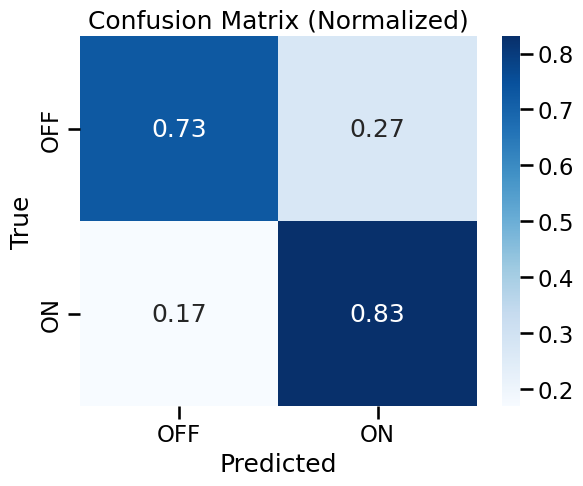

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:448: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.loc[start:end].iloc[:96, df.columns.get_loc('hvac_mode_pred')] = pred_vals
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_1

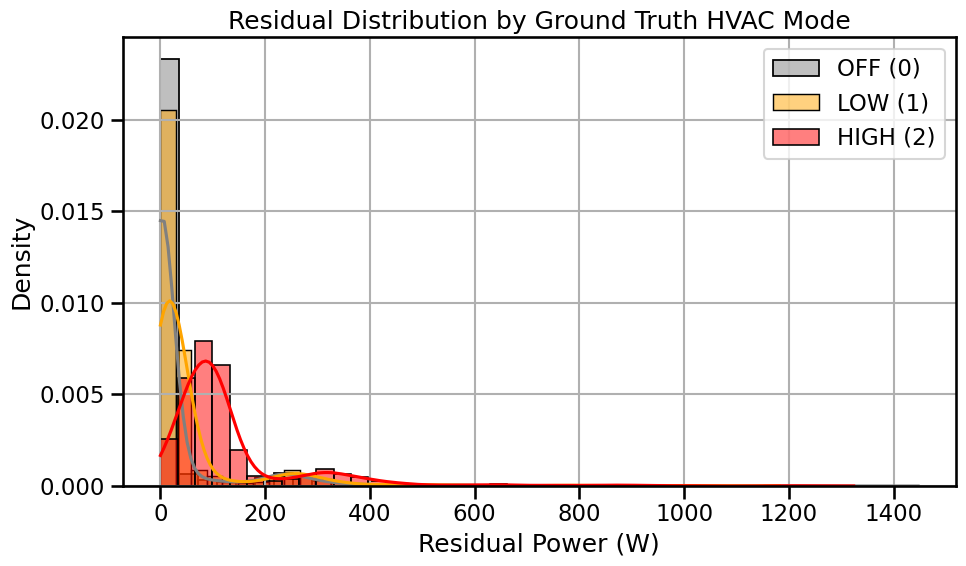

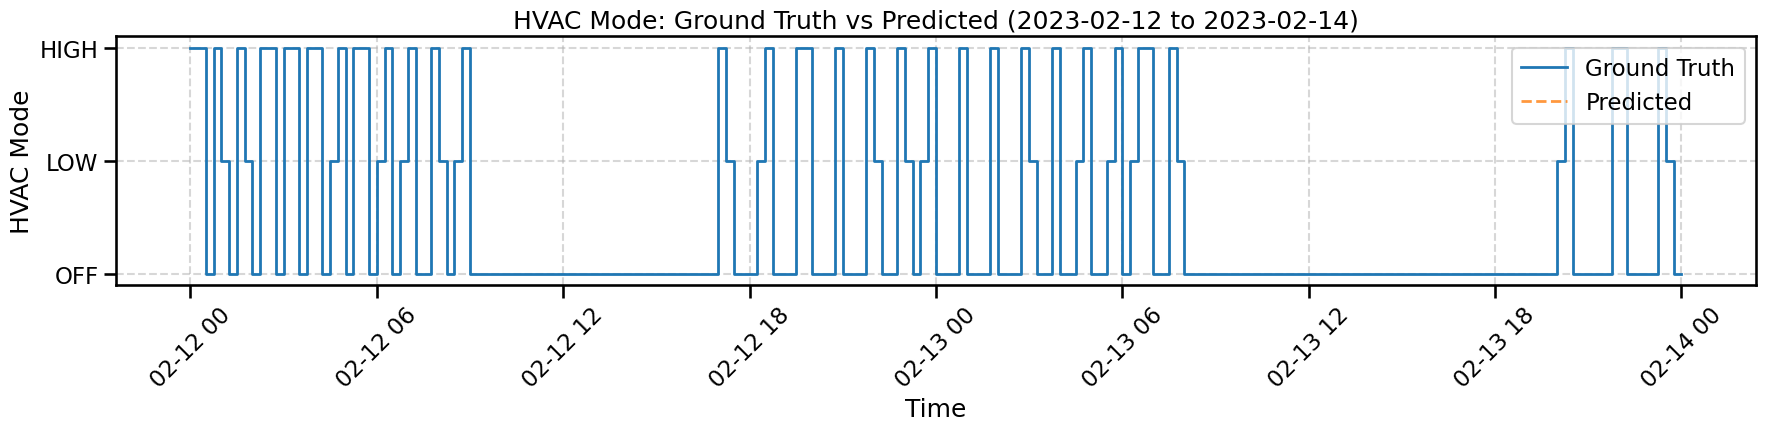

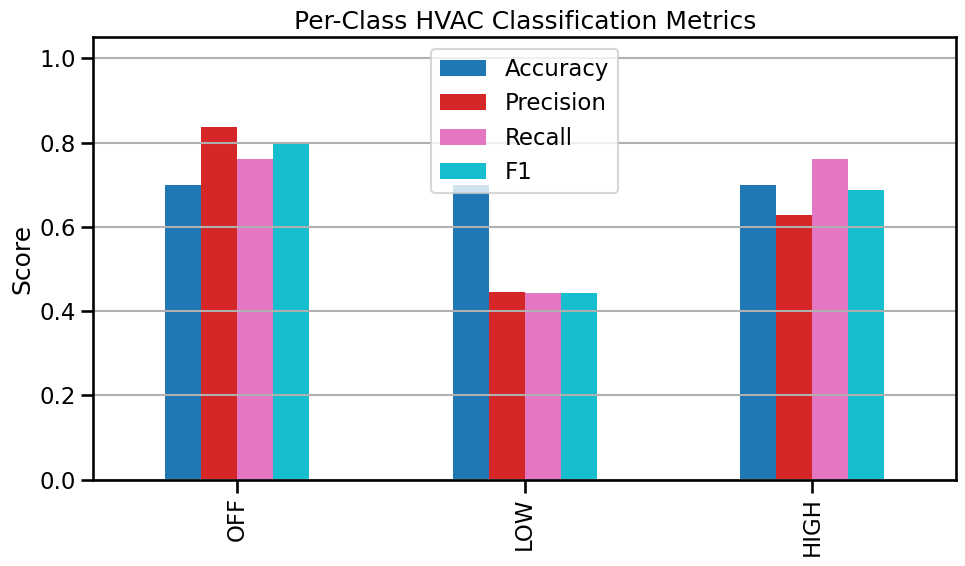

→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.84      0.76      0.80      6976
         LOW       0.44      0.44      0.44      2373
        HIGH       0.63      0.76      0.69      3035

    accuracy                           0.70     12384
   macro avg       0.64      0.66      0.64     12384
weighted avg       0.71      0.70      0.70     12384



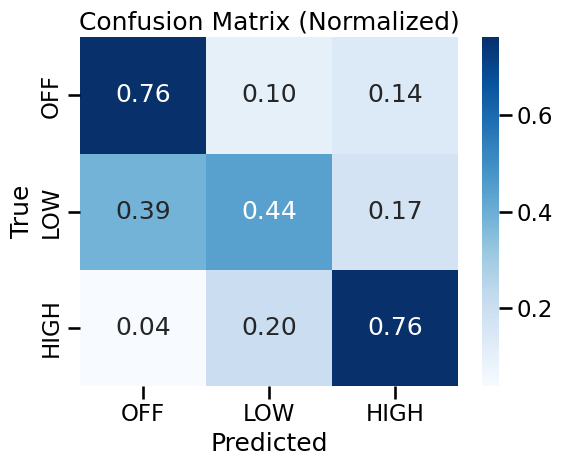

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'



=== ICA Pipeline ===

== ICA pipeline (with temp bounds + HMM smoothing) ==
→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.57      0.77      0.65      6976
         LOW       0.15      0.05      0.08      2373
        HIGH       0.23      0.16      0.18      3035

    accuracy                           0.48     12384
   macro avg       0.31      0.33      0.30     12384
weighted avg       0.40      0.48      0.43     12384



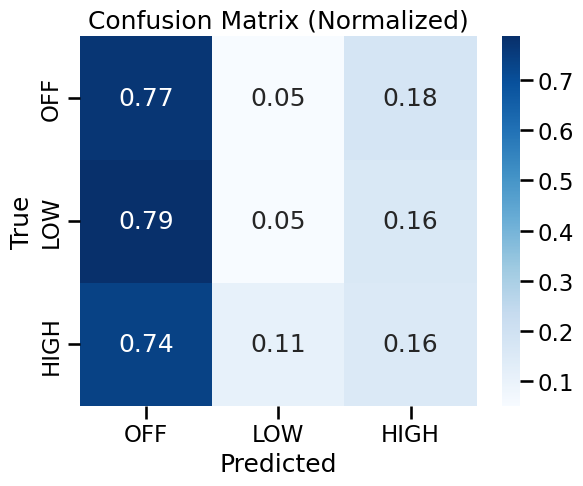

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:468: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ts = pd.date_range(start=start_ica, periods=96*len(days_ica), freq='15T')[:H_ica.size].to_pydatetime()


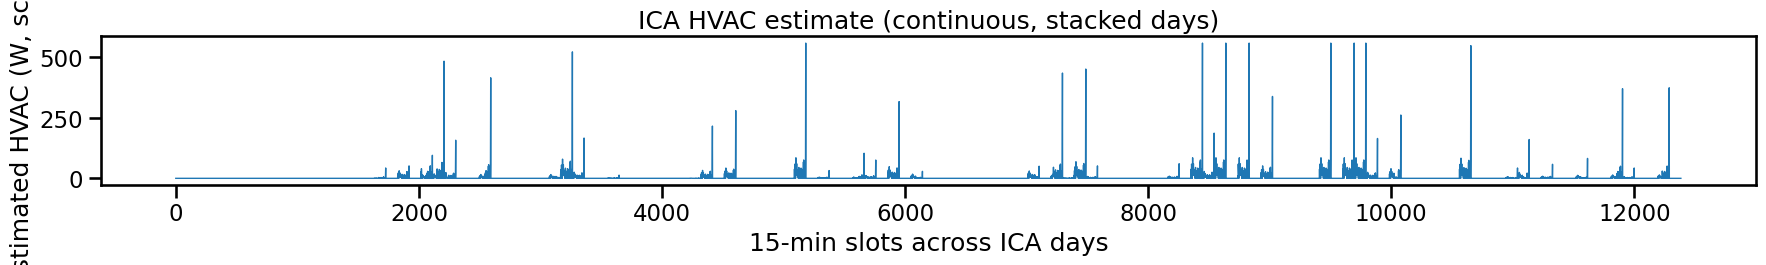

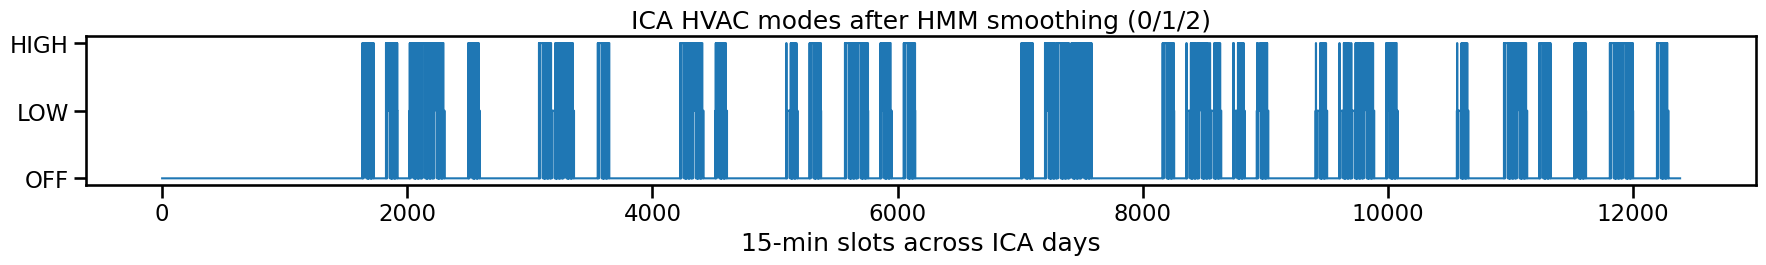

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[load_col] = df[load_col].fillna(method='ffill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)


Total LIUL slots replaced: 57
→ Classification Report:
              precision    recall  f1-score   support

         OFF       0.72      0.93      0.81      4226
          ON       0.96      0.81      0.88      8158

    accuracy                           0.85     12384
   macro avg       0.84      0.87      0.85     12384
weighted avg       0.88      0.85      0.86     12384



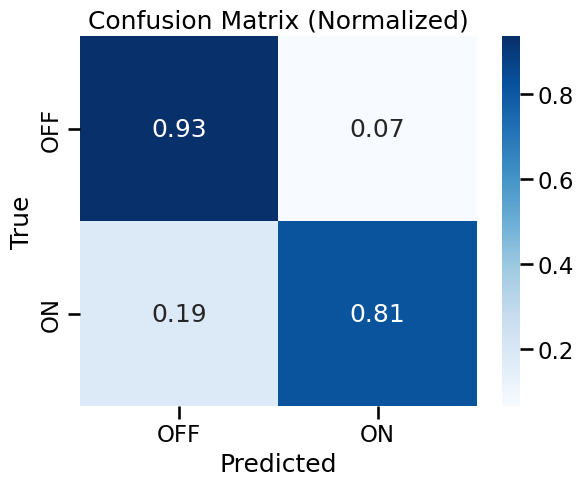

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:448: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.loc[start:end].iloc[:96, df.columns.get_loc('hvac_mode_pred')] = pred_vals
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_1

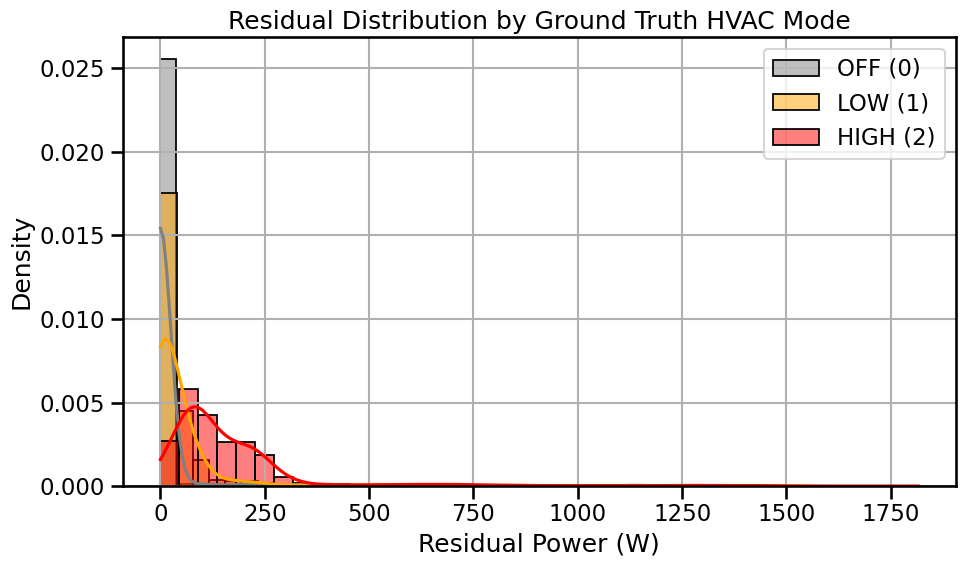

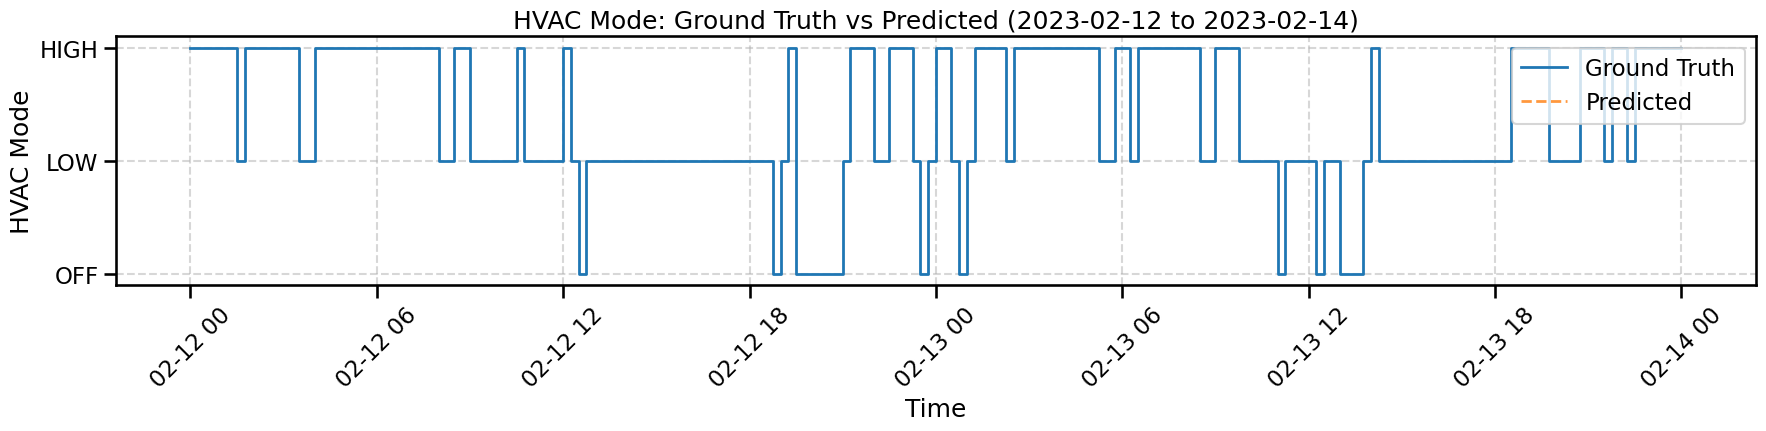

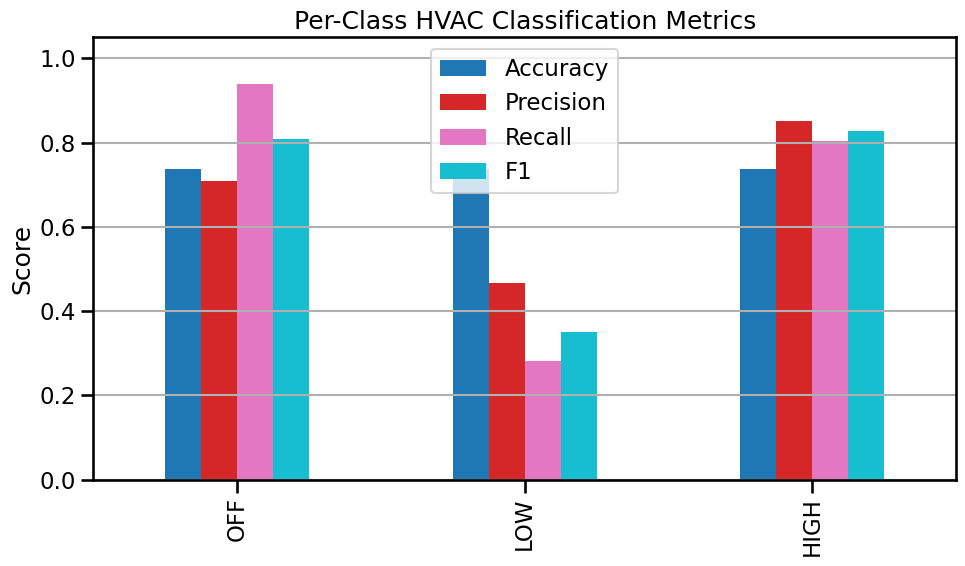

→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.71      0.94      0.81      4226
         LOW       0.47      0.28      0.35      2679
        HIGH       0.85      0.80      0.83      5479

    accuracy                           0.74     12384
   macro avg       0.68      0.67      0.66     12384
weighted avg       0.72      0.74      0.72     12384



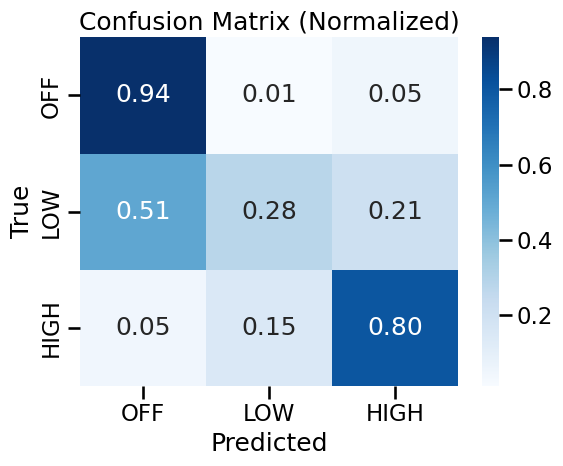

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'



=== ICA Pipeline ===

== ICA pipeline (with temp bounds + HMM smoothing) ==
→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.31      0.55      0.39      4226
         LOW       0.21      0.11      0.15      2679
        HIGH       0.38      0.23      0.28      5479

    accuracy                           0.31     12384
   macro avg       0.30      0.30      0.27     12384
weighted avg       0.32      0.31      0.29     12384



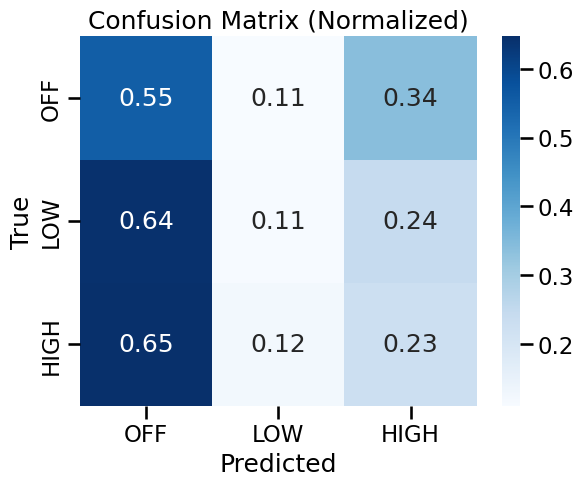

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:468: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ts = pd.date_range(start=start_ica, periods=96*len(days_ica), freq='15T')[:H_ica.size].to_pydatetime()


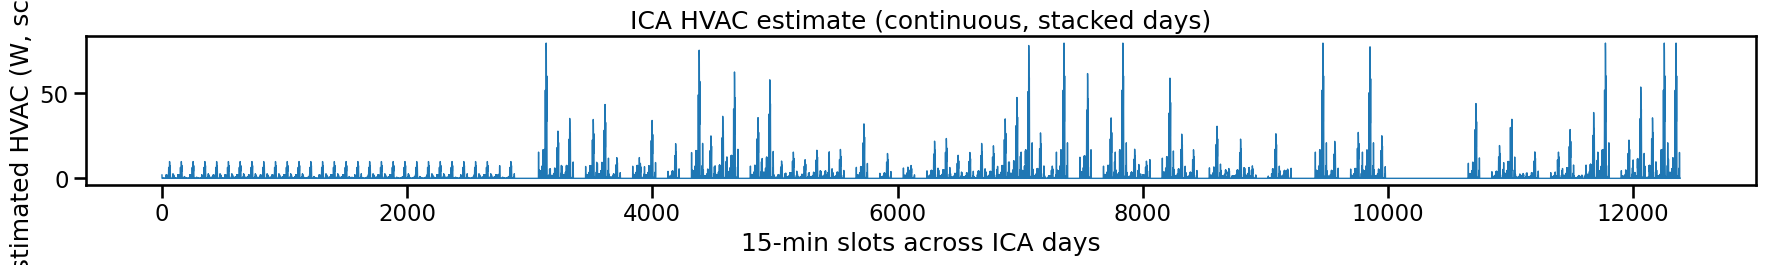

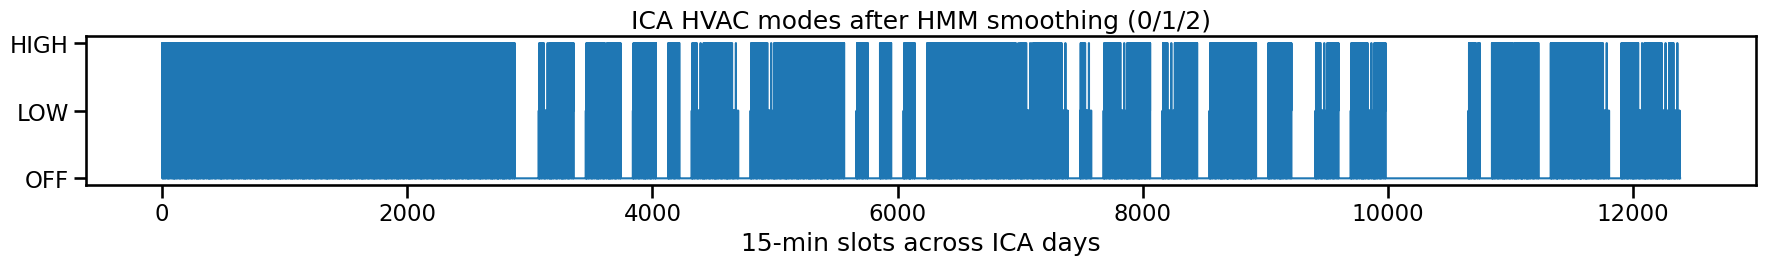

Total LIUL slots replaced: 80
→ Classification Report:
              precision    recall  f1-score   support

         OFF       0.68      0.53      0.60      6065
          ON       0.63      0.76      0.69      6319

    accuracy                           0.65     12384
   macro avg       0.65      0.65      0.64     12384
weighted avg       0.65      0.65      0.64     12384



C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[load_col] = df[load_col].fillna(method='ffill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)


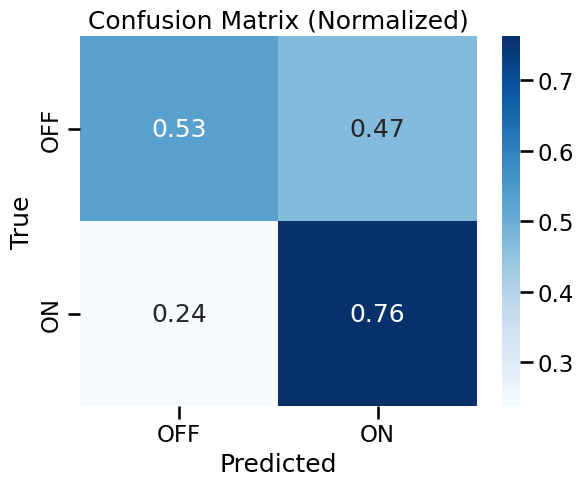

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:448: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.loc[start:end].iloc[:96, df.columns.get_loc('hvac_mode_pred')] = pred_vals
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_1

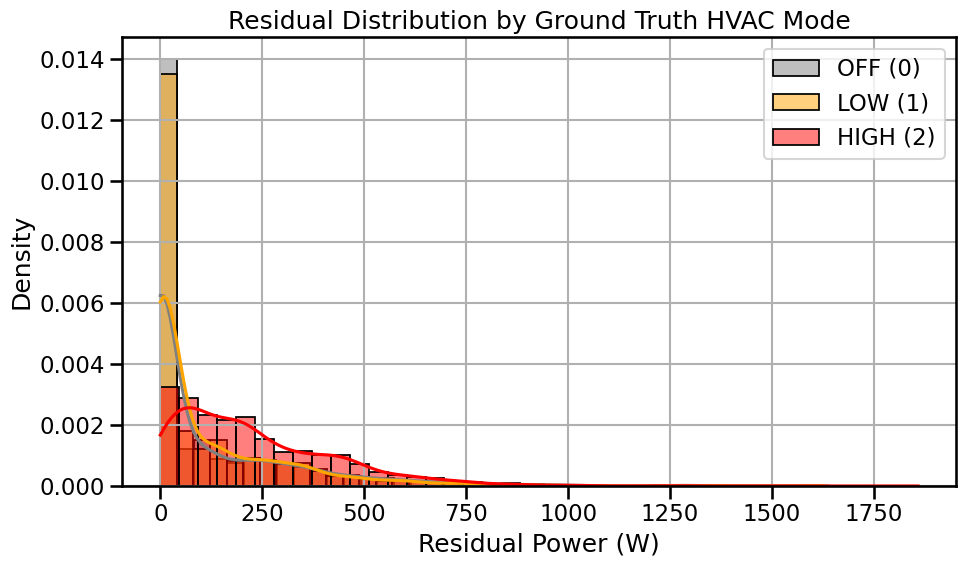

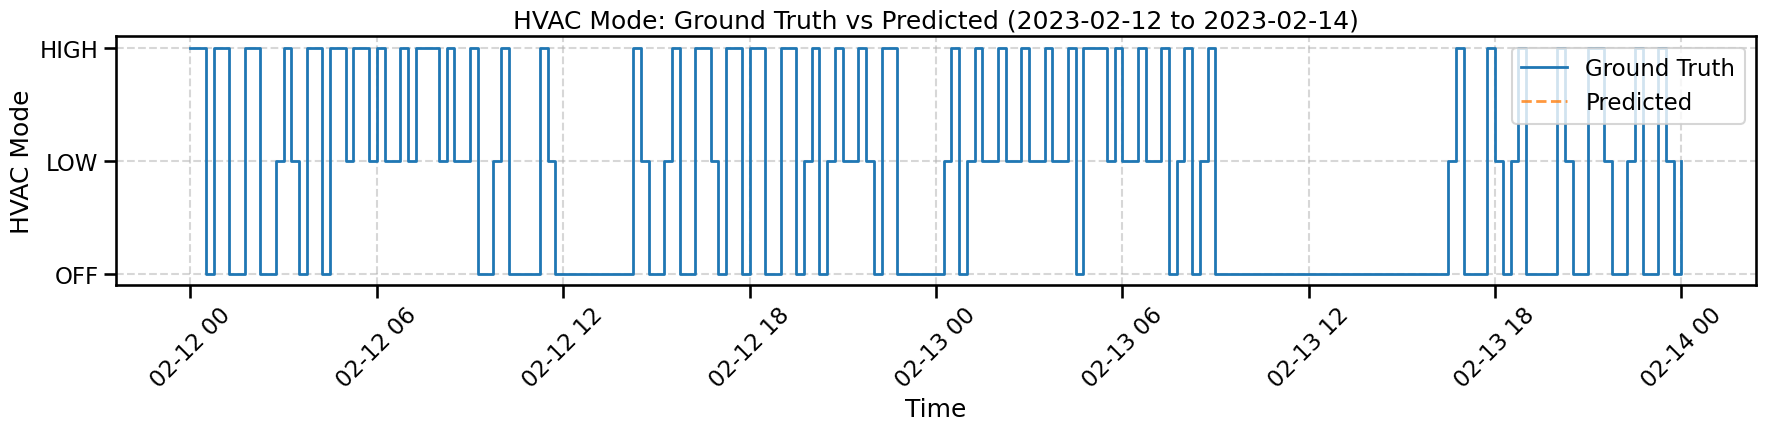

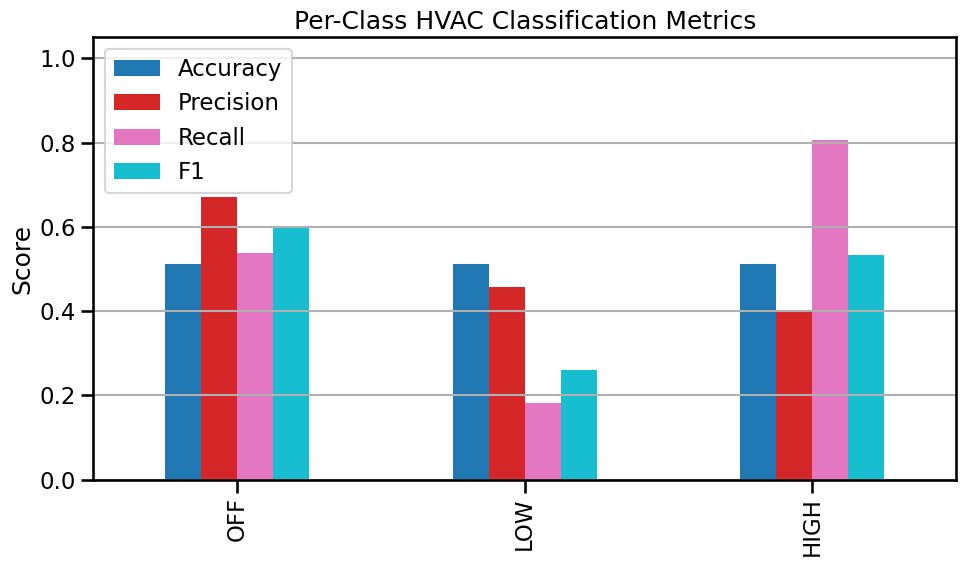

→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.67      0.54      0.60      6065
         LOW       0.46      0.18      0.26      3232
        HIGH       0.40      0.81      0.53      3087

    accuracy                           0.51     12384
   macro avg       0.51      0.51      0.46     12384
weighted avg       0.55      0.51      0.49     12384



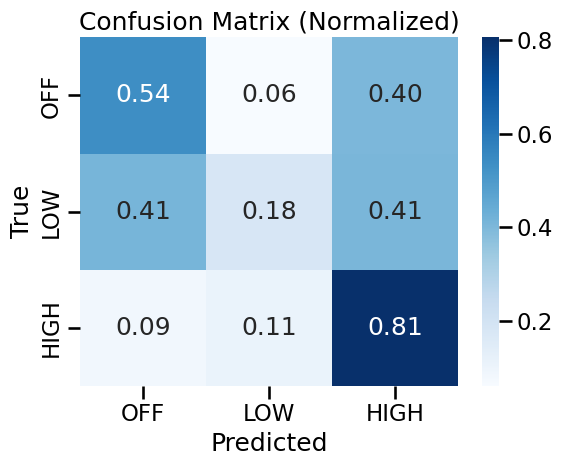

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'



=== ICA Pipeline ===

== ICA pipeline (with temp bounds + HMM smoothing) ==
→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.50      0.79      0.61      6065
         LOW       0.23      0.07      0.10      3232
        HIGH       0.27      0.16      0.20      3087

    accuracy                           0.45     12384
   macro avg       0.33      0.34      0.31     12384
weighted avg       0.37      0.45      0.38     12384



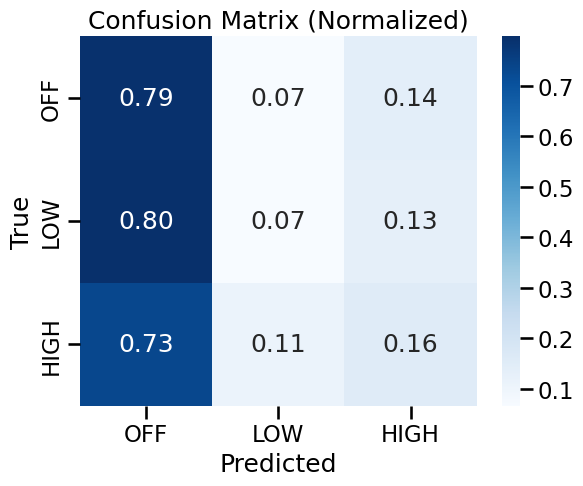

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:468: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ts = pd.date_range(start=start_ica, periods=96*len(days_ica), freq='15T')[:H_ica.size].to_pydatetime()


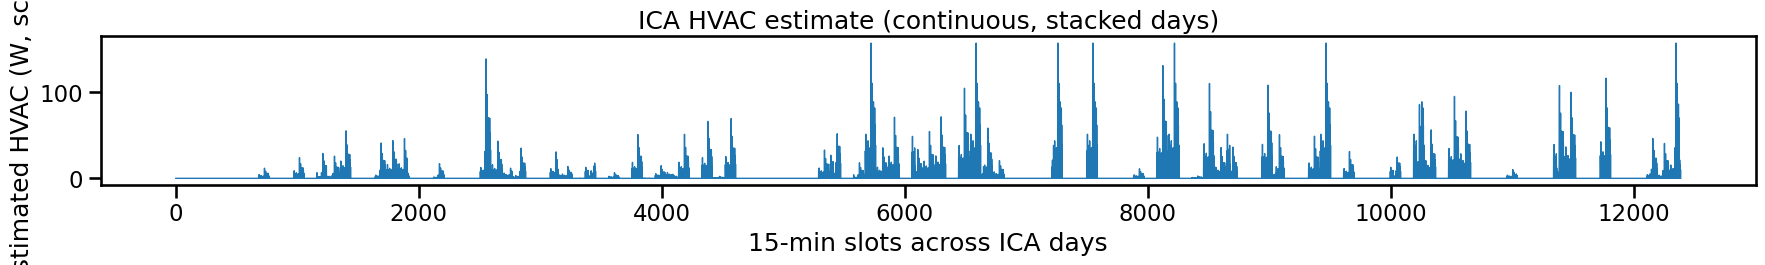

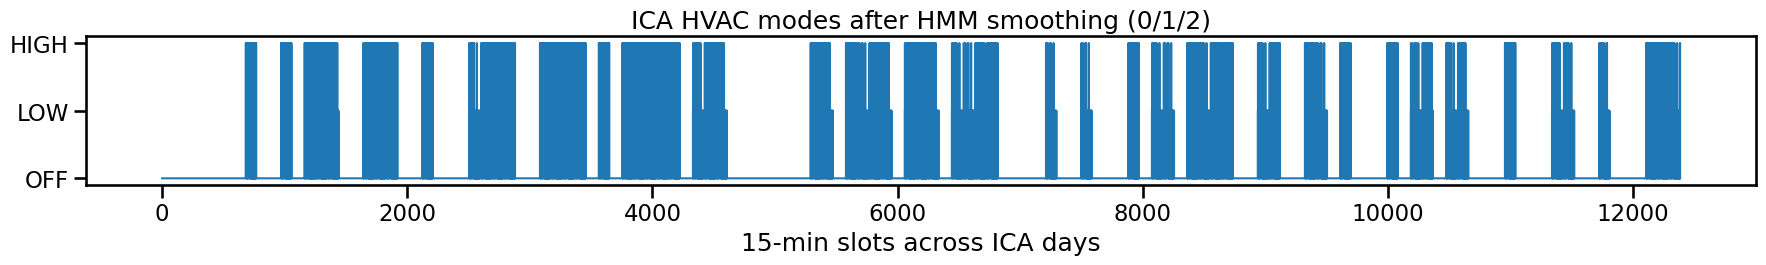

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[load_col] = df[load_col].fillna(method='ffill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)


Total LIUL slots replaced: 75
→ Classification Report:
              precision    recall  f1-score   support

         OFF       0.75      0.90      0.82      3838
          ON       0.95      0.86      0.90      8546

    accuracy                           0.87     12384
   macro avg       0.85      0.88      0.86     12384
weighted avg       0.89      0.87      0.88     12384



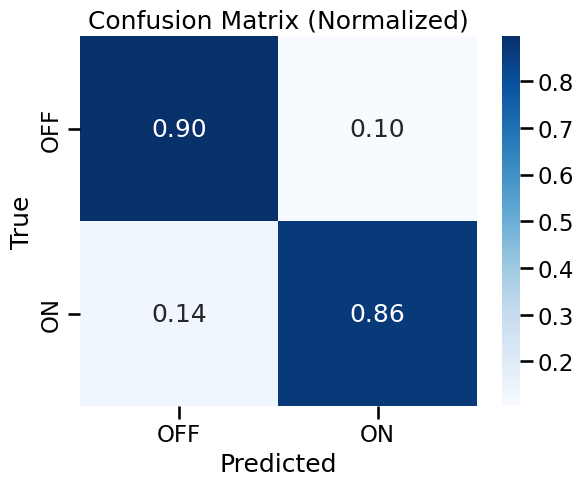

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:448: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.loc[start:end].iloc[:96, df.columns.get_loc('hvac_mode_pred')] = pred_vals
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_1

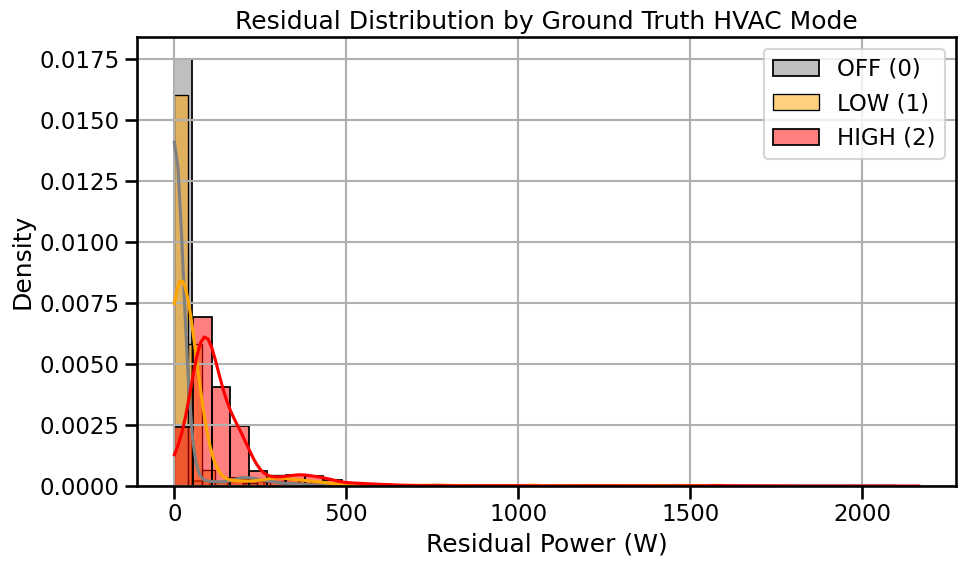

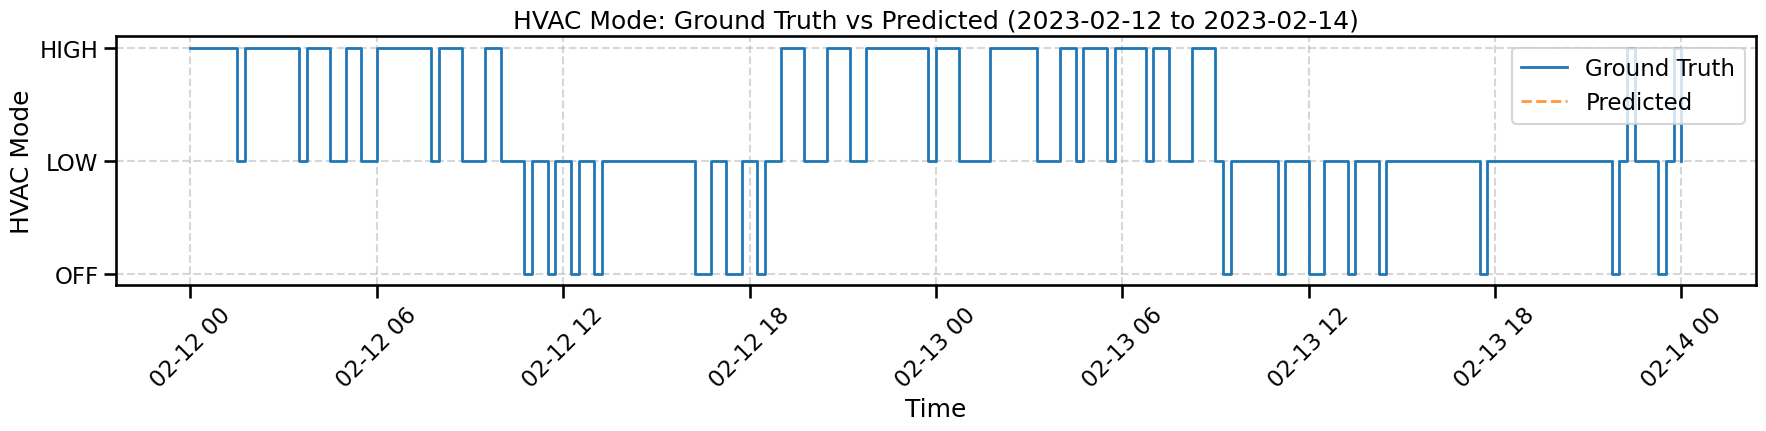

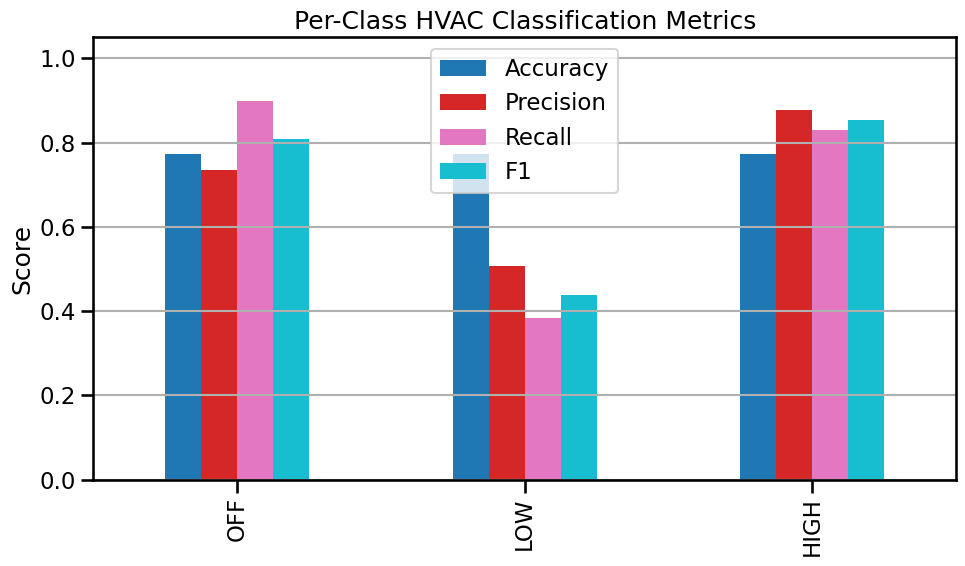

→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.73      0.90      0.81      3838
         LOW       0.51      0.39      0.44      2184
        HIGH       0.88      0.83      0.85      6362

    accuracy                           0.77     12384
   macro avg       0.71      0.71      0.70     12384
weighted avg       0.77      0.77      0.77     12384



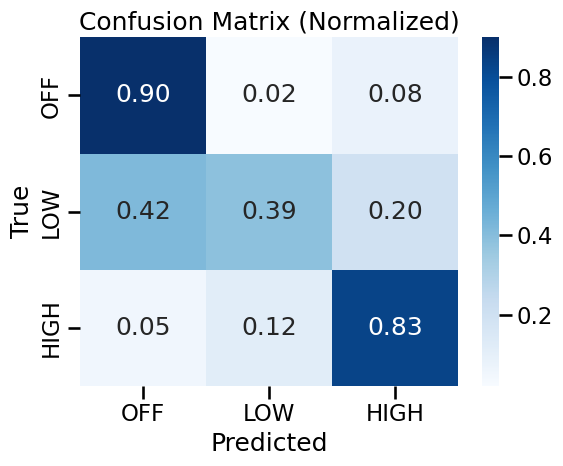

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'



=== ICA Pipeline ===

== ICA pipeline (with temp bounds + HMM smoothing) ==
→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.33      0.96      0.49      3838
         LOW       0.12      0.03      0.04      2184
        HIGH       0.70      0.09      0.17      6362

    accuracy                           0.35     12384
   macro avg       0.38      0.36      0.23     12384
weighted avg       0.48      0.35      0.25     12384



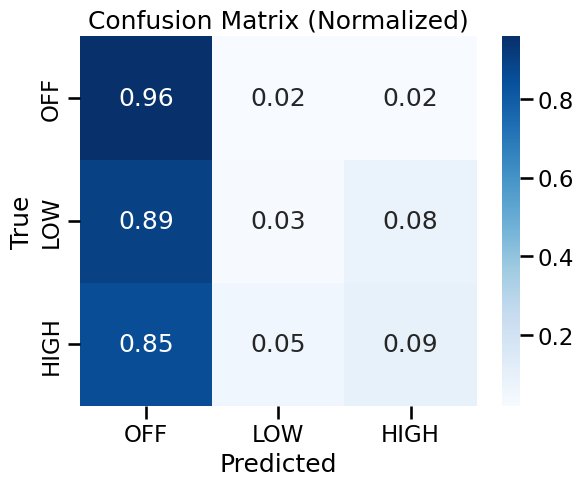

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:468: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ts = pd.date_range(start=start_ica, periods=96*len(days_ica), freq='15T')[:H_ica.size].to_pydatetime()


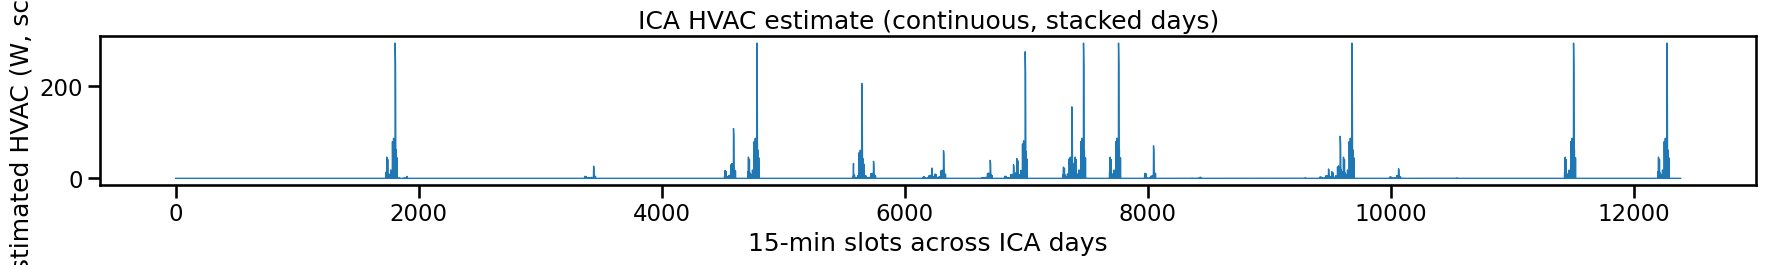

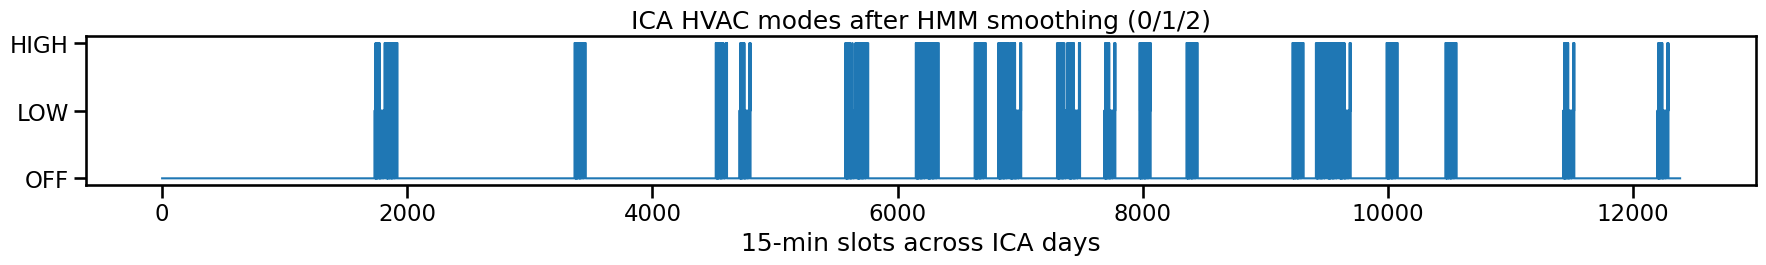

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[load_col] = df[load_col].fillna(method='ffill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)


Total LIUL slots replaced: 86
→ Classification Report:
              precision    recall  f1-score   support

         OFF       0.87      0.71      0.78      9248
          ON       0.44      0.67      0.53      3136

    accuracy                           0.70     12384
   macro avg       0.65      0.69      0.66     12384
weighted avg       0.76      0.70      0.72     12384



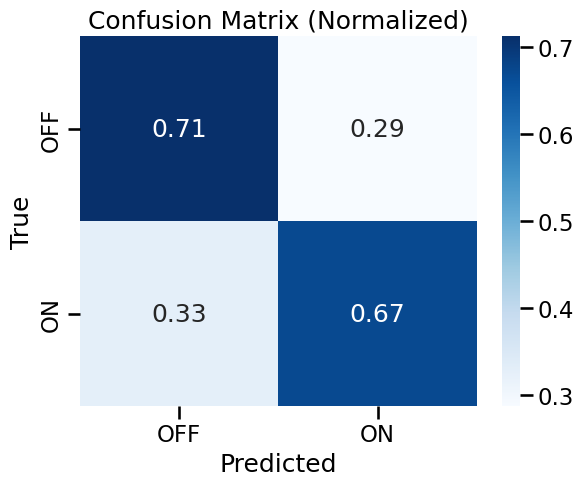

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:448: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.loc[start:end].iloc[:96, df.columns.get_loc('hvac_mode_pred')] = pred_vals
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_1

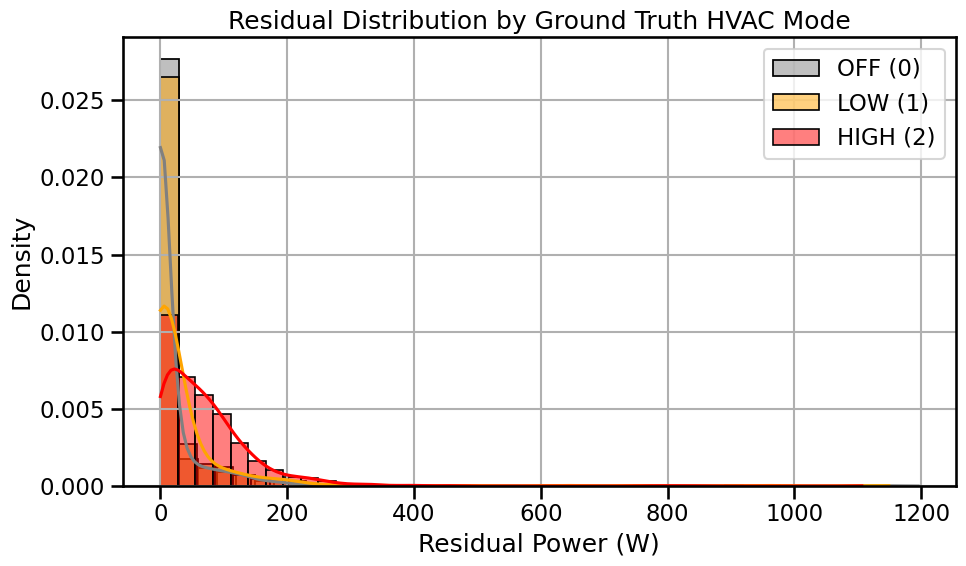

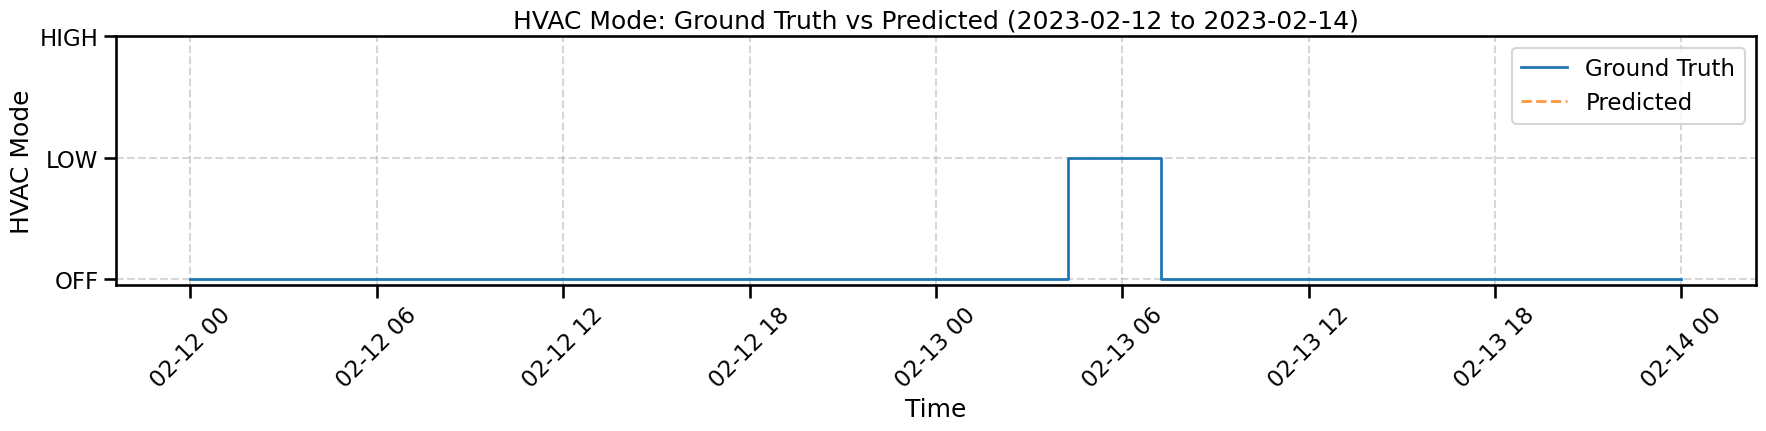

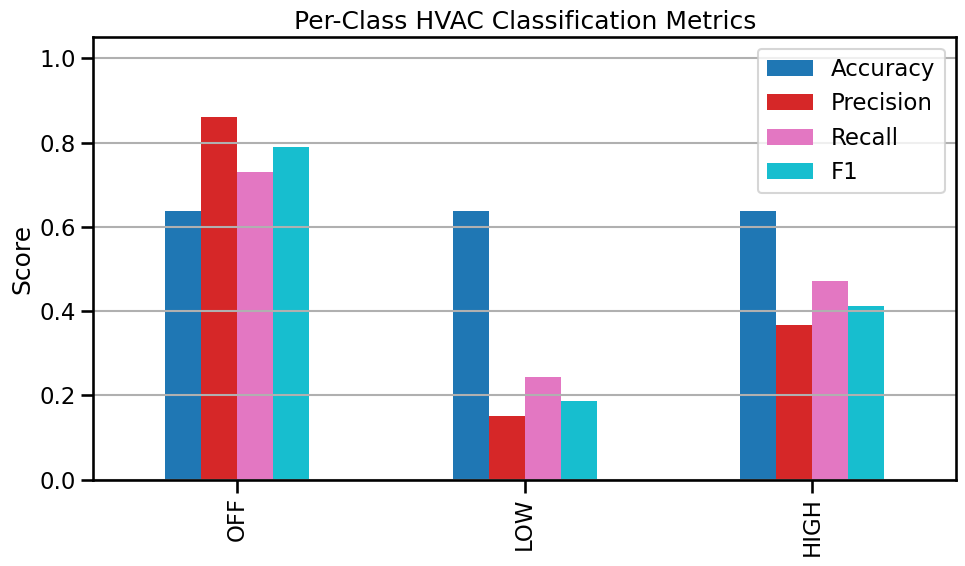

→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.86      0.73      0.79      9248
         LOW       0.15      0.24      0.19      1494
        HIGH       0.37      0.47      0.41      1642

    accuracy                           0.64     12384
   macro avg       0.46      0.48      0.46     12384
weighted avg       0.71      0.64      0.67     12384



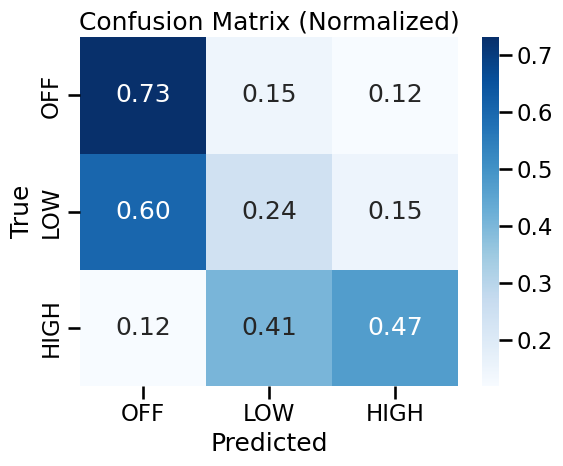

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'



=== ICA Pipeline ===

== ICA pipeline (with temp bounds + HMM smoothing) ==
→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.76      0.80      0.78      9248
         LOW       0.21      0.09      0.12      1494
        HIGH       0.14      0.17      0.16      1642

    accuracy                           0.63     12384
   macro avg       0.37      0.35      0.35     12384
weighted avg       0.61      0.63      0.62     12384



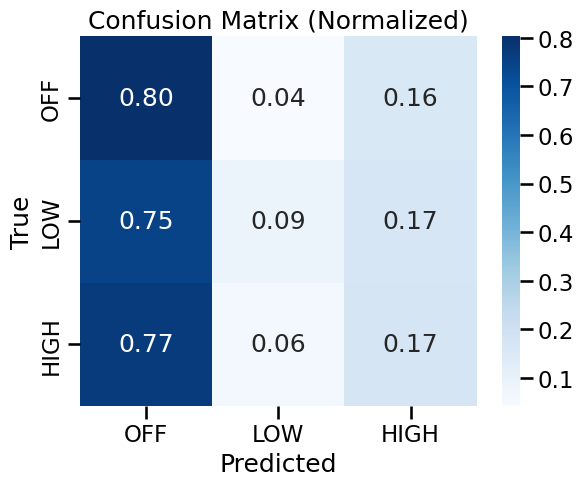

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:468: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ts = pd.date_range(start=start_ica, periods=96*len(days_ica), freq='15T')[:H_ica.size].to_pydatetime()


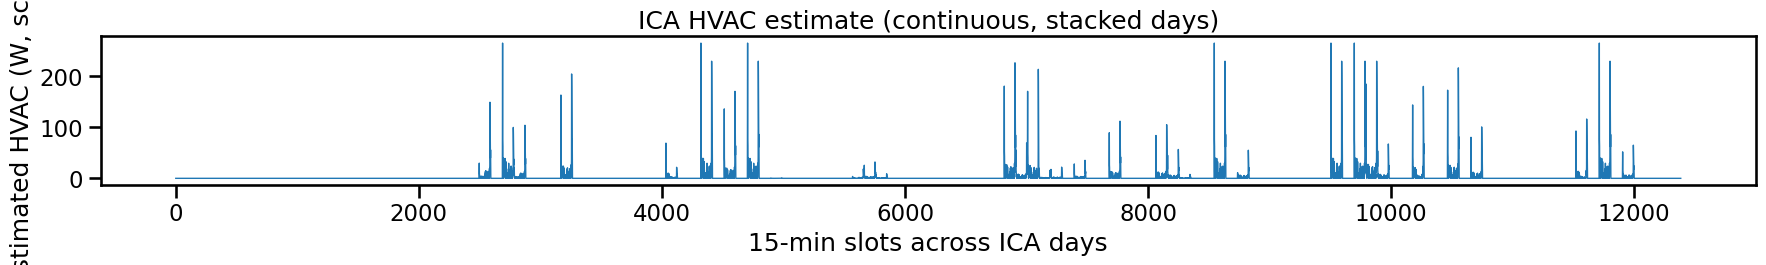

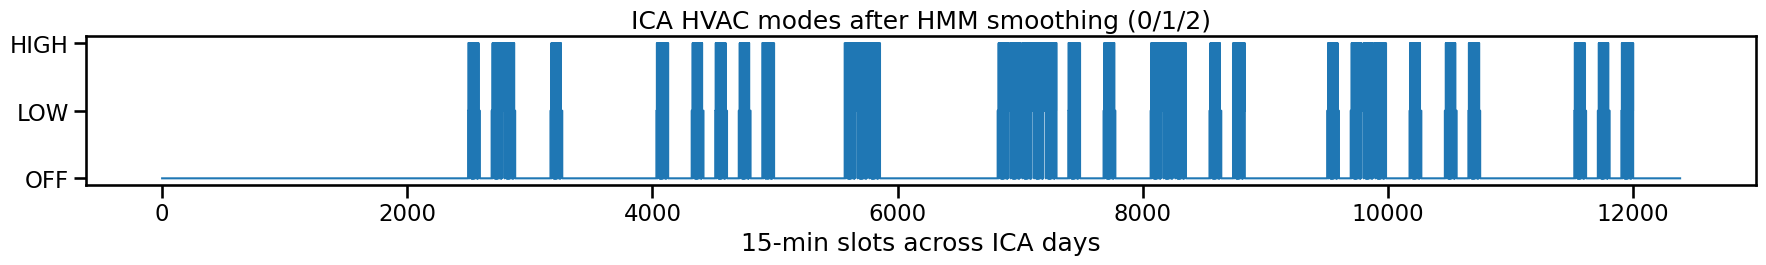

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[load_col] = df[load_col].fillna(method='ffill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)


Total LIUL slots replaced: 87
→ Classification Report:
              precision    recall  f1-score   support

         OFF       0.77      0.76      0.77      5615
          ON       0.80      0.81      0.81      6769

    accuracy                           0.79     12384
   macro avg       0.79      0.79      0.79     12384
weighted avg       0.79      0.79      0.79     12384



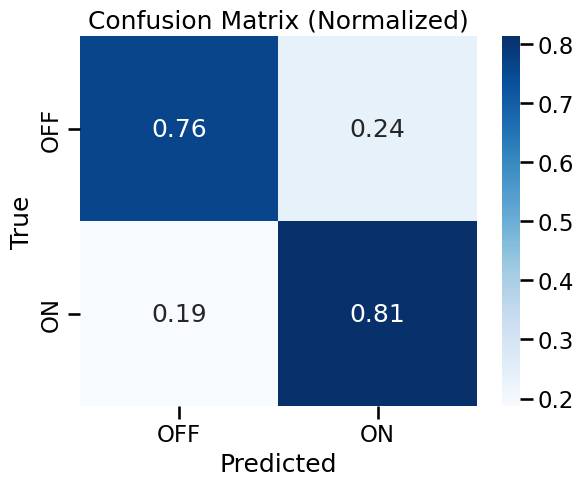

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:448: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.loc[start:end].iloc[:96, df.columns.get_loc('hvac_mode_pred')] = pred_vals
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_1

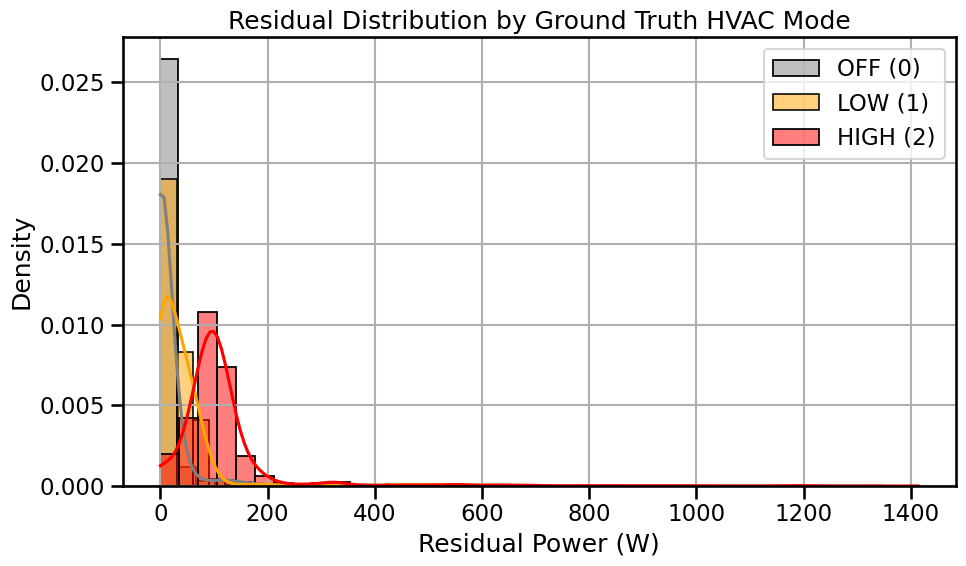

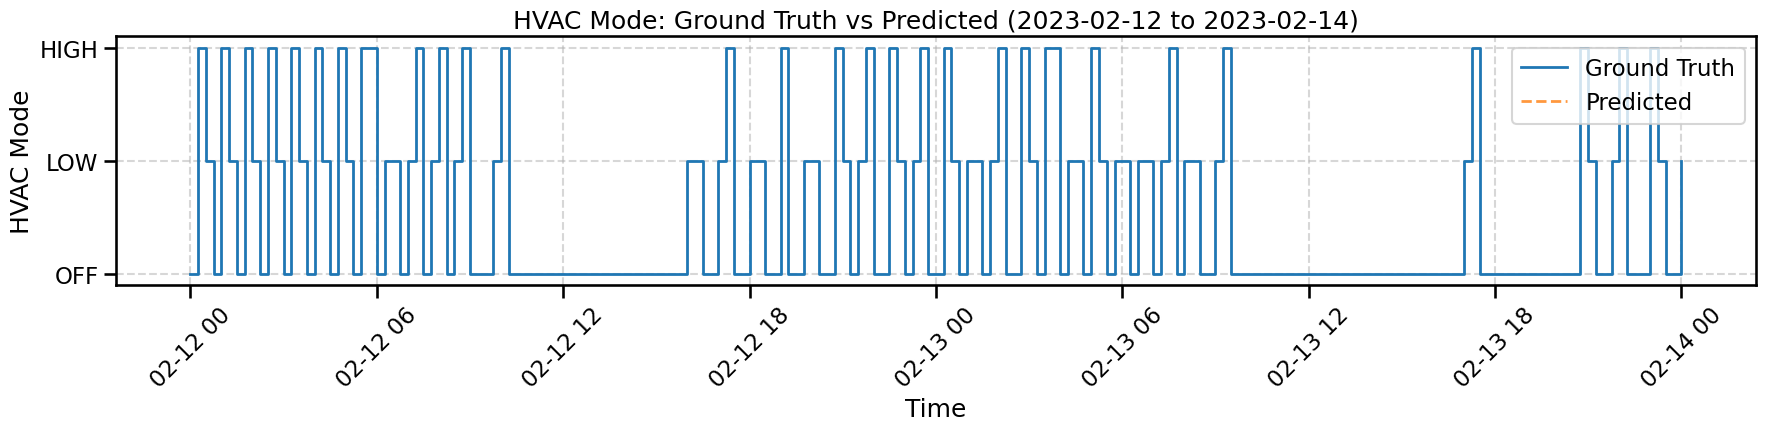

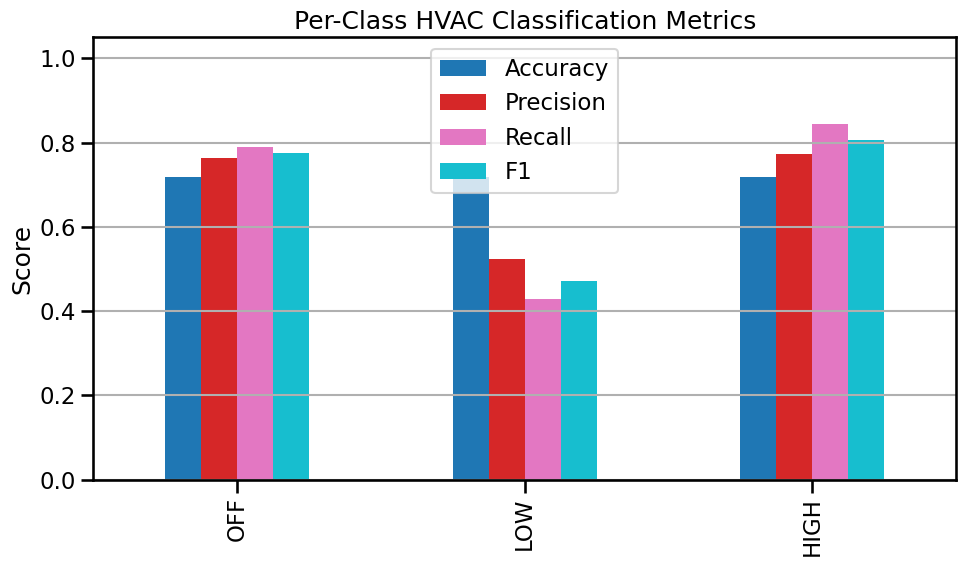

→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.76      0.79      0.78      5615
         LOW       0.52      0.43      0.47      3019
        HIGH       0.77      0.84      0.81      3750

    accuracy                           0.72     12384
   macro avg       0.69      0.69      0.69     12384
weighted avg       0.71      0.72      0.71     12384



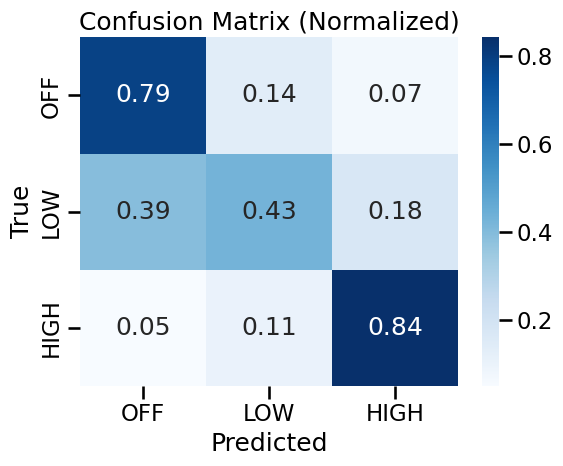

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'



=== ICA Pipeline ===

== ICA pipeline (with temp bounds + HMM smoothing) ==
→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.26      0.25      0.26      5615
         LOW       0.20      0.22      0.21      3019
        HIGH       0.20      0.18      0.19      3750

    accuracy                           0.22     12384
   macro avg       0.22      0.22      0.22     12384
weighted avg       0.22      0.22      0.22     12384



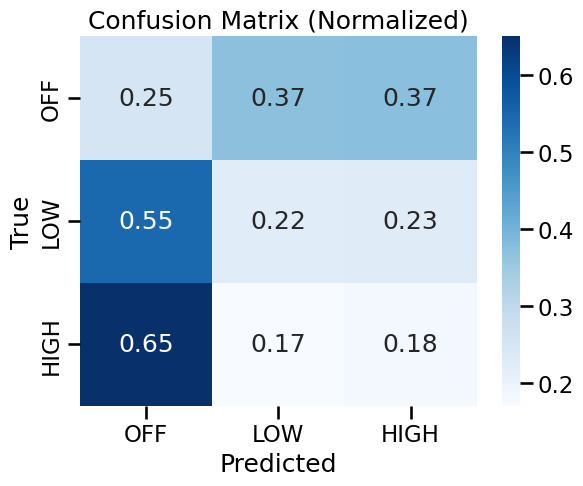

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:468: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ts = pd.date_range(start=start_ica, periods=96*len(days_ica), freq='15T')[:H_ica.size].to_pydatetime()


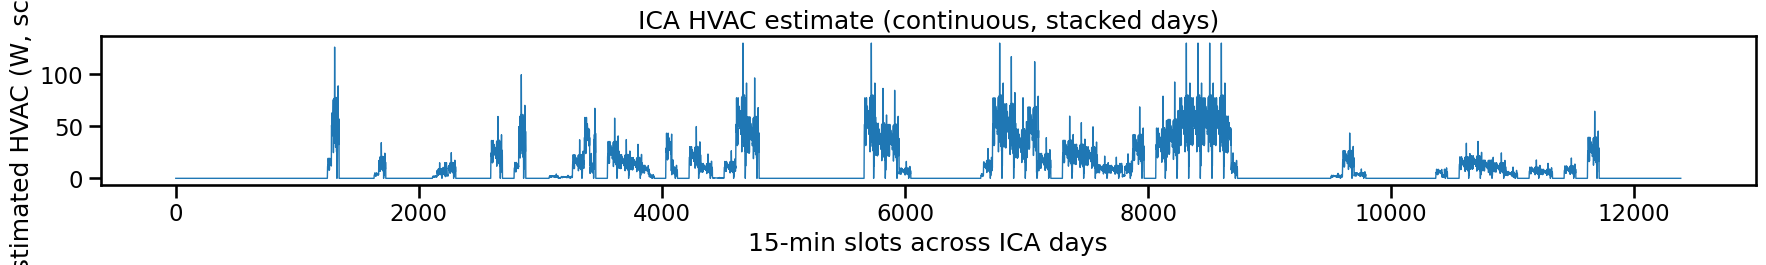

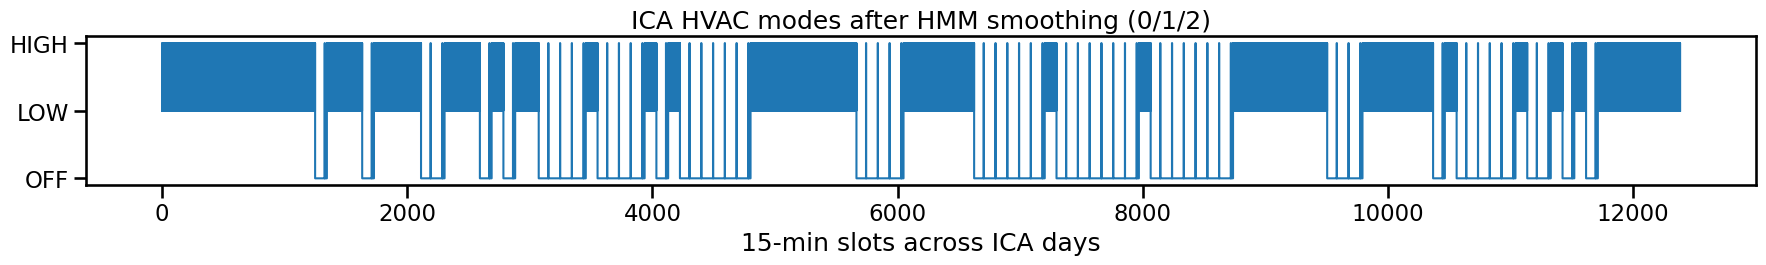

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[load_col] = df[load_col].fillna(method='ffill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)


Total LIUL slots replaced: 82
→ Classification Report:
              precision    recall  f1-score   support

         OFF       0.50      0.89      0.64      3560
          ON       0.94      0.64      0.76      8824

    accuracy                           0.71     12384
   macro avg       0.72      0.76      0.70     12384
weighted avg       0.81      0.71      0.72     12384



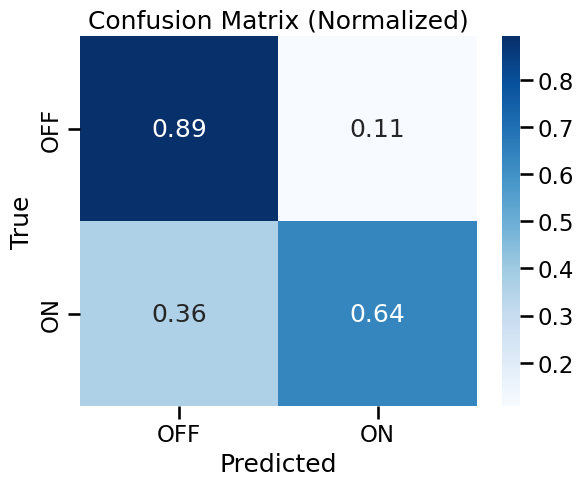

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:448: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.loc[start:end].iloc[:96, df.columns.get_loc('hvac_mode_pred')] = pred_vals
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_1

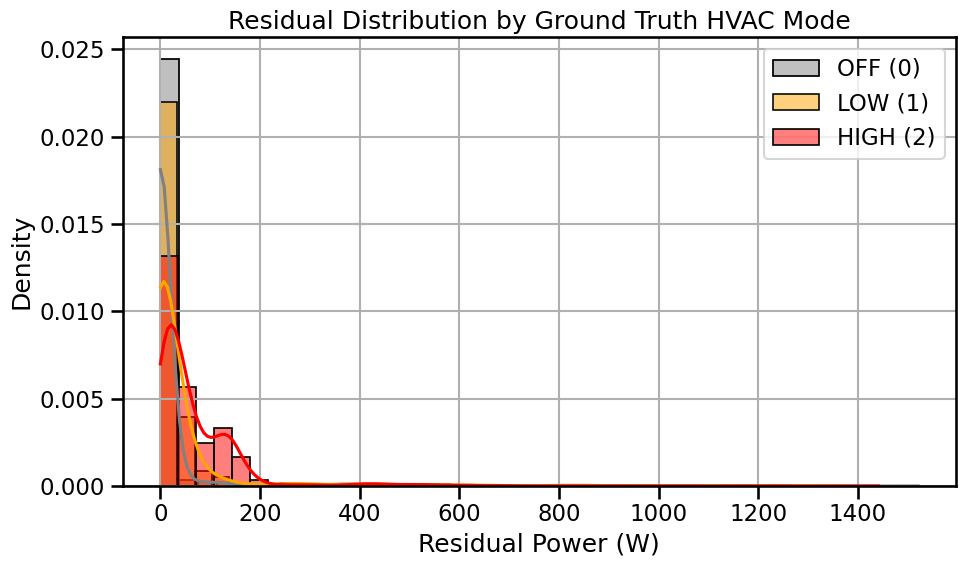

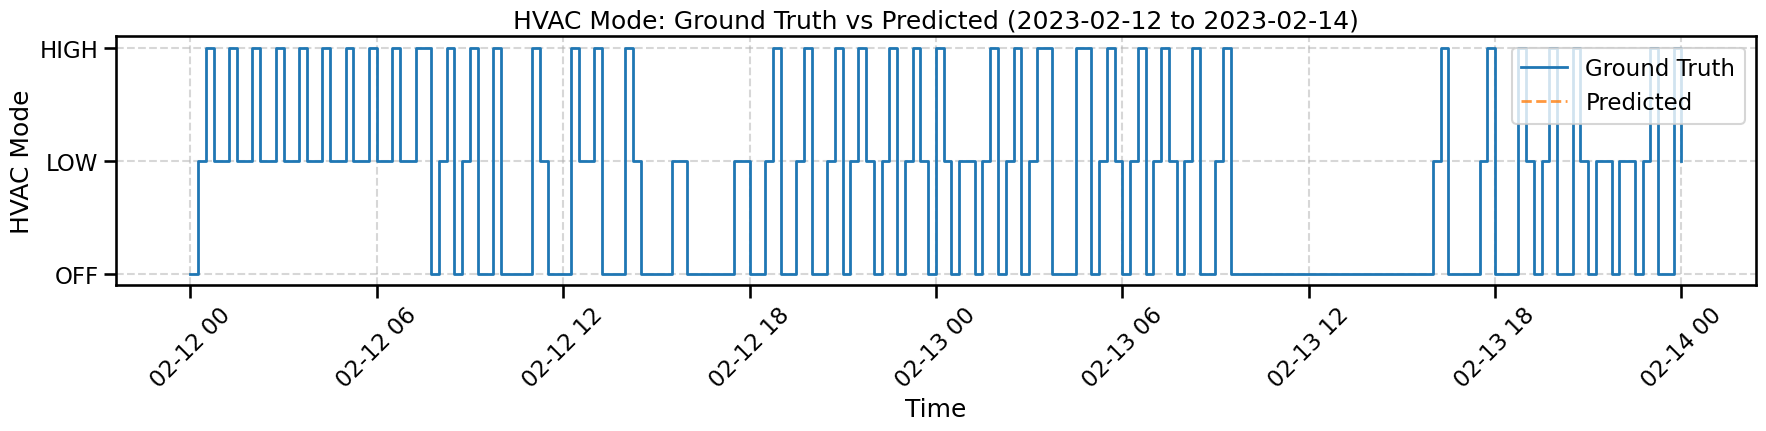

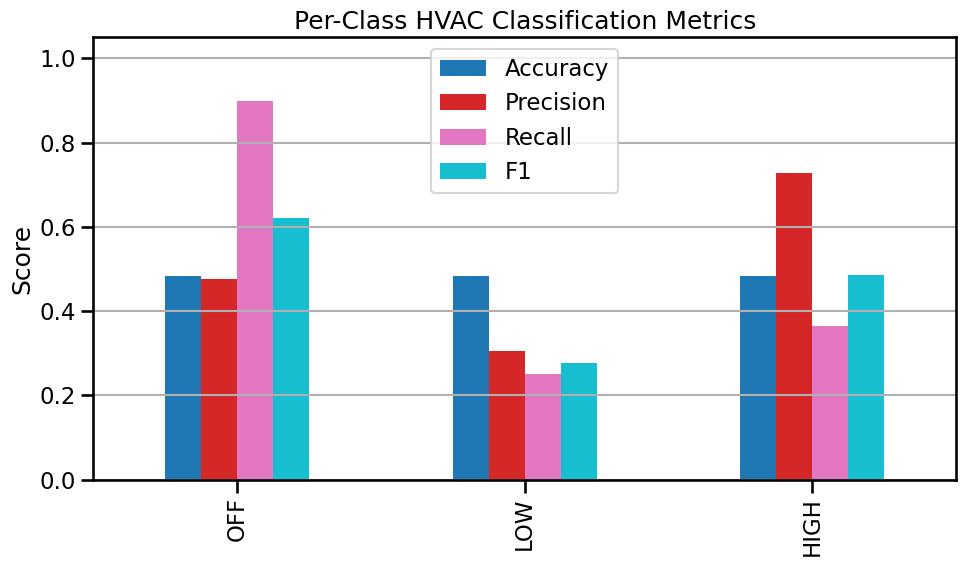

→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.48      0.90      0.62      3560
         LOW       0.30      0.25      0.28      3804
        HIGH       0.73      0.36      0.49      5020

    accuracy                           0.48     12384
   macro avg       0.50      0.50      0.46     12384
weighted avg       0.53      0.48      0.46     12384



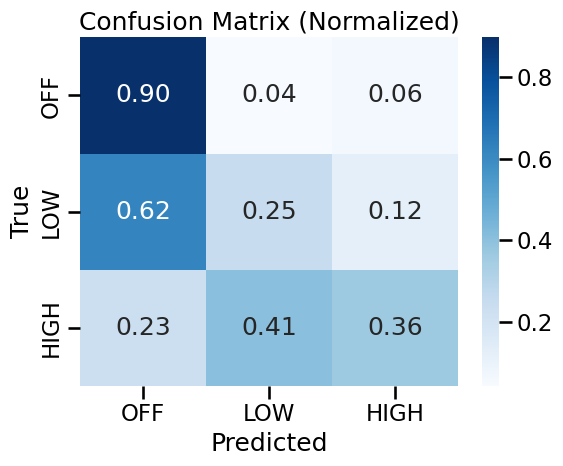

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'



=== ICA Pipeline ===

== ICA pipeline (with temp bounds + HMM smoothing) ==
→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.28      0.55      0.37      3560
         LOW       0.26      0.23      0.25      3804
        HIGH       0.59      0.25      0.35      5020

    accuracy                           0.33     12384
   macro avg       0.38      0.34      0.32     12384
weighted avg       0.40      0.33      0.32     12384



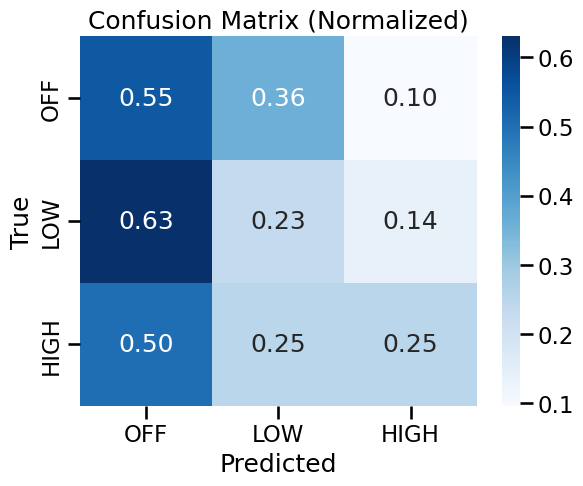

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:468: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ts = pd.date_range(start=start_ica, periods=96*len(days_ica), freq='15T')[:H_ica.size].to_pydatetime()


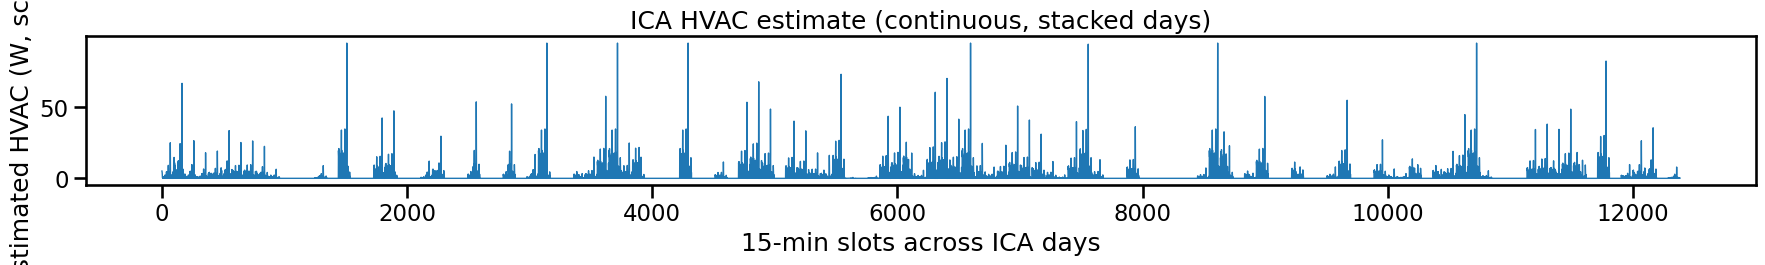

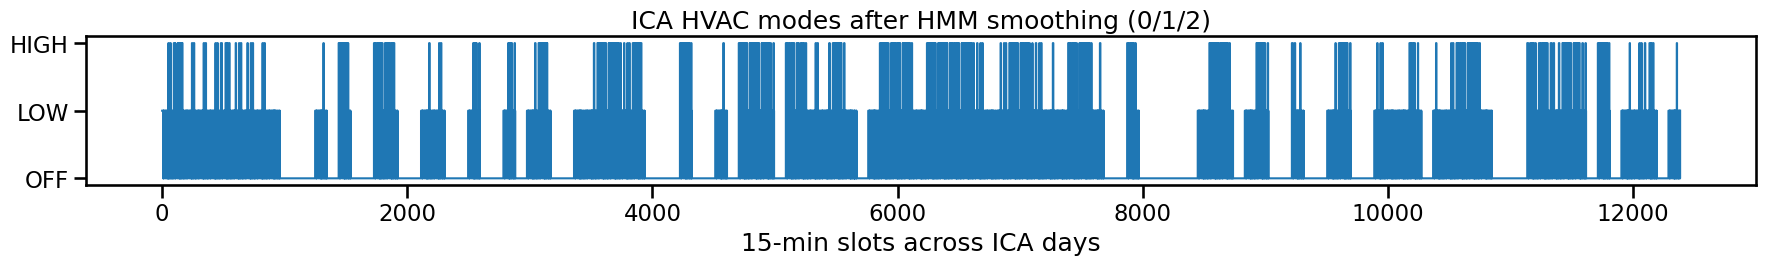

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[load_col] = df[load_col].fillna(method='ffill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)


Total LIUL slots replaced: 73
→ Classification Report:
              precision    recall  f1-score   support

         OFF       0.35      0.87      0.50      1954
          ON       0.97      0.70      0.81     10430

    accuracy                           0.73     12384
   macro avg       0.66      0.78      0.66     12384
weighted avg       0.87      0.73      0.76     12384



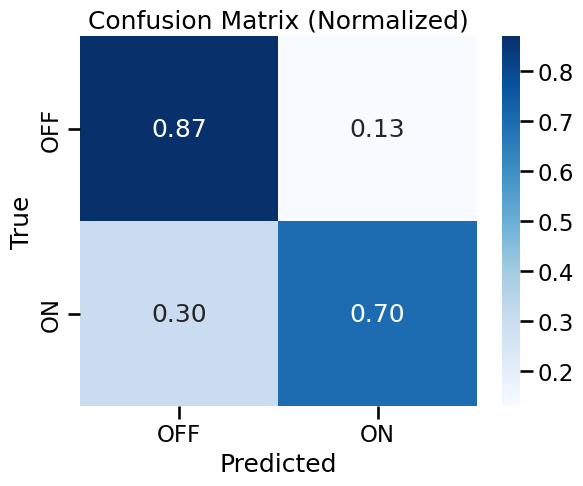

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:448: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.loc[start:end].iloc[:96, df.columns.get_loc('hvac_mode_pred')] = pred_vals
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_1

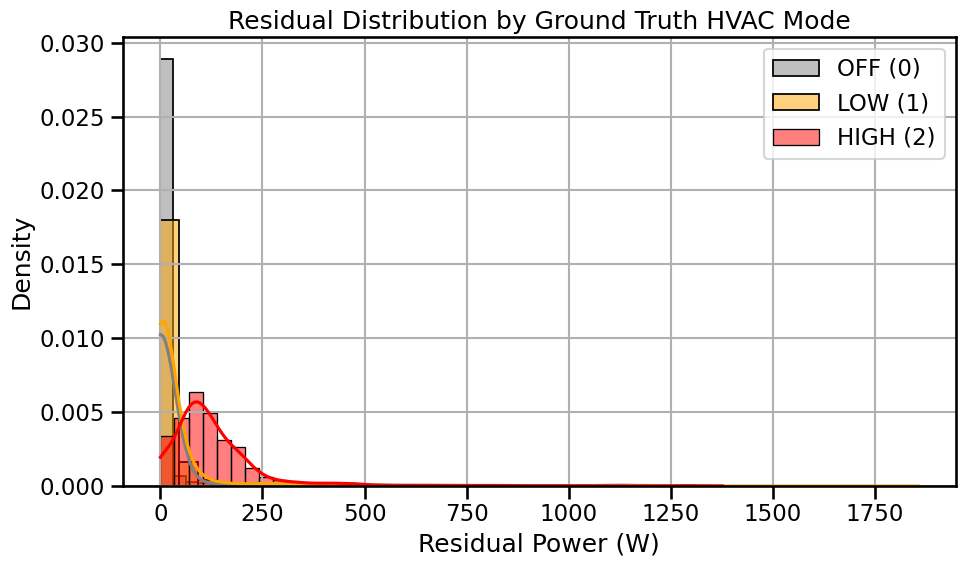

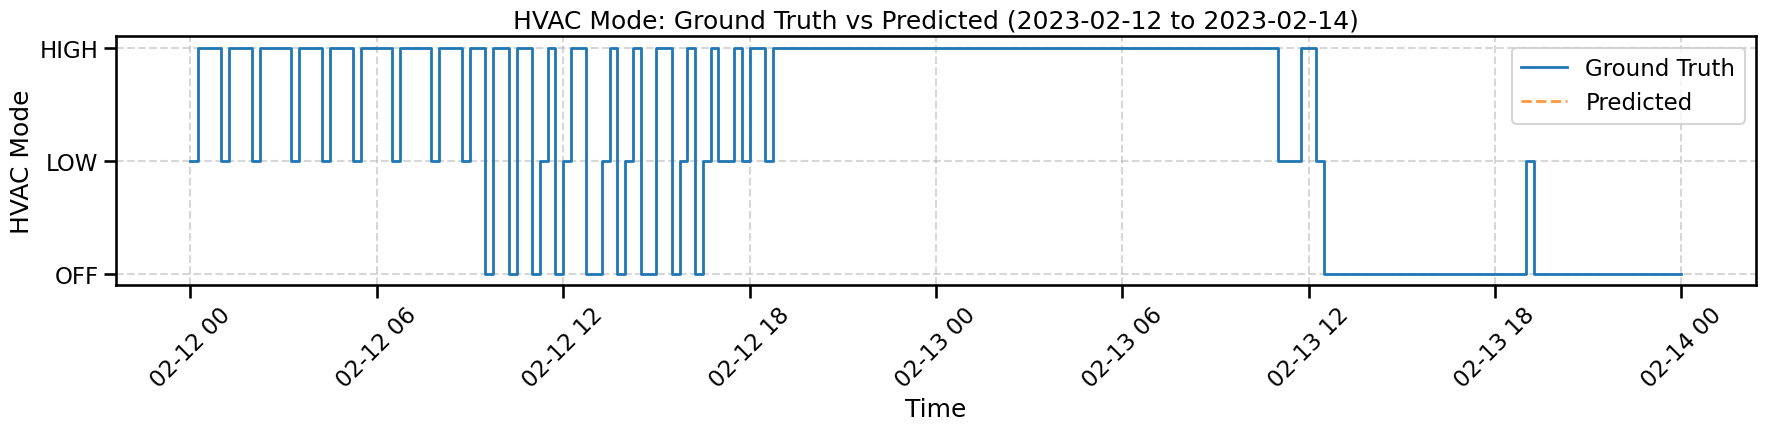

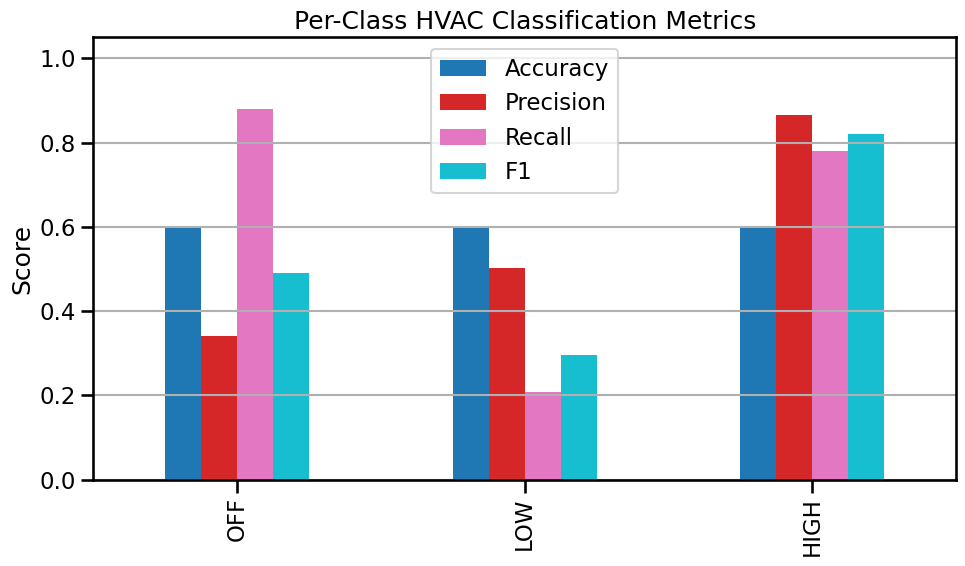

→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.34      0.88      0.49      1954
         LOW       0.50      0.21      0.30      4260
        HIGH       0.87      0.78      0.82      6170

    accuracy                           0.60     12384
   macro avg       0.57      0.62      0.54     12384
weighted avg       0.66      0.60      0.59     12384



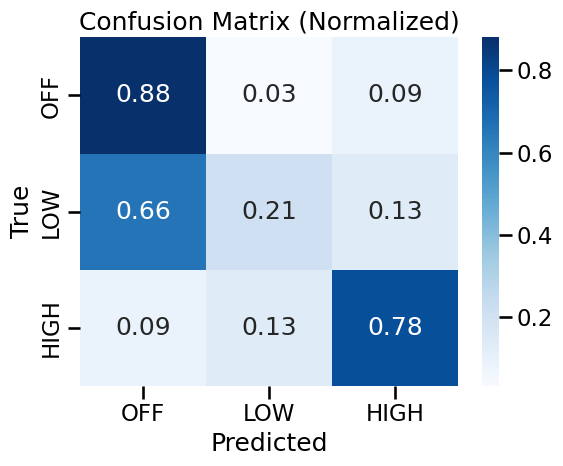

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'



=== ICA Pipeline ===

== ICA pipeline (with temp bounds + HMM smoothing) ==
→ Multiclass Classification Report:
              precision    recall  f1-score   support

         OFF       0.21      0.72      0.33      1954
         LOW       0.16      0.21      0.18      4260
        HIGH       0.63      0.05      0.08      6170

    accuracy                           0.21     12384
   macro avg       0.34      0.32      0.20     12384
weighted avg       0.40      0.21      0.16     12384



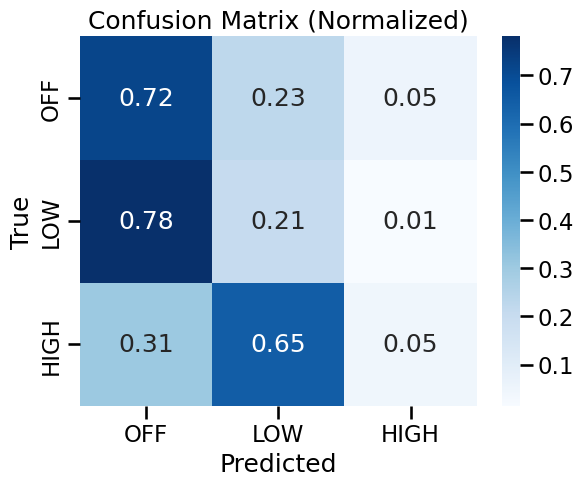

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\709177878.py:468: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ts = pd.date_range(start=start_ica, periods=96*len(days_ica), freq='15T')[:H_ica.size].to_pydatetime()


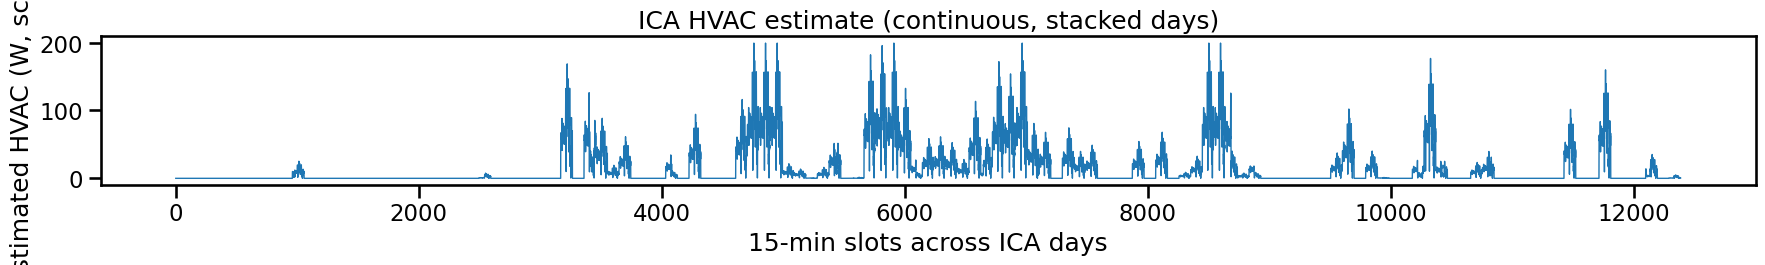

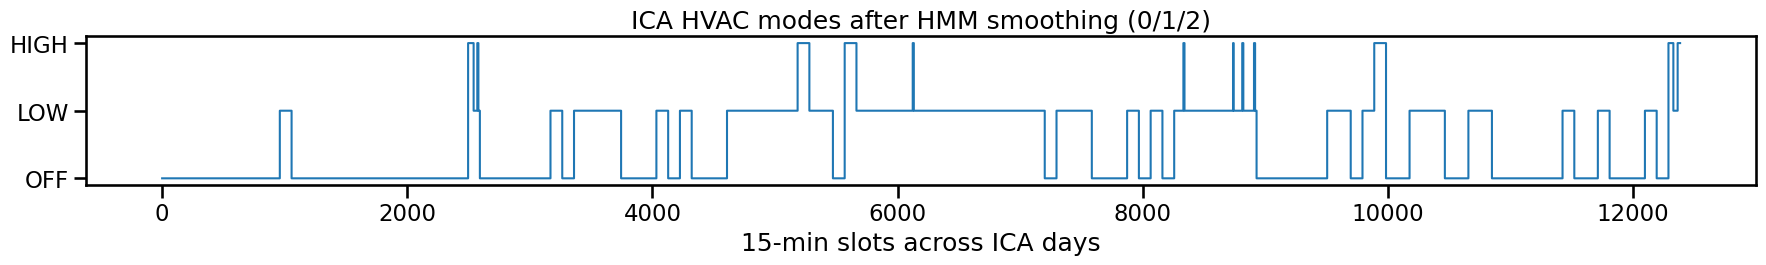

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.decomposition import FastICA
from sklearn.preprocessing import StandardScaler

def make_daily_profiles(df, load_col='total_energy'):
    df = df.copy()
    df[load_col] = df[load_col].fillna(method='ffill')
    df['day'] = df.index.floor('D')
    df['slot'] = ((df.index - df['day']) / pd.Timedelta('15T')).astype(int)
    daily = df.pivot(index='day', columns='slot', values=load_col)
    return daily.dropna()

def classify_days_by_temp(df, temp_col='Tout', low_pct=35, high_pct=85):
    daily_temp = df[temp_col].resample('D').mean()
    t_low, t_high = np.percentile(daily_temp.dropna(), [low_pct, high_pct])
    mild_days = daily_temp[(daily_temp >= t_low) & (daily_temp <= t_high)].index
    hvac_days = daily_temp.index.difference(mild_days)
    return list(mild_days), list(hvac_days), t_low, t_high

def plot_ternary_metrics(pred, true):
    labels = [0, 1, 2]
    metrics = {
        "Accuracy": [accuracy_score(true.flatten(), pred.flatten())] * 3,
        "Precision": precision_score(true.flatten(), pred.flatten(), average=None, labels=labels),
        "Recall": recall_score(true.flatten(), pred.flatten(), average=None, labels=labels),
        "F1": f1_score(true.flatten(), pred.flatten(), average=None, labels=labels)
    }

    df = pd.DataFrame(metrics, index=["OFF", "LOW", "HIGH"])
    df.plot(kind="bar", figsize=(10, 6), colormap="tab10")
    plt.title("Per-Class HVAC Classification Metrics")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

def extract_simple_residual(df, daily_profiles, mild_days, hvac_days, t_low, t_high, temp_col='Tout'):
    baseline = daily_profiles.loc[mild_days].median(axis=0).values
    residuals = []
    kept_days = []

    for day in hvac_days:
        if day not in daily_profiles.index:
            continue

        profile = daily_profiles.loc[day].values
        Tout = df[temp_col].loc[day : day + pd.Timedelta(days=1)].values[:96]

        hvac_active_mask = (Tout < t_low) | (Tout > t_high)
        if not hvac_active_mask.any():
            continue  

        resid = np.zeros(96)
        resid[hvac_active_mask] = np.clip(profile - baseline, a_min=0, a_max=None)[hvac_active_mask]
        residuals.append(resid)
        kept_days.append(day)

    return np.vstack(residuals), kept_days

def build_ground_truth_matrix(df, days, col='hvac_mode'):
    df['hvac_binary'] = df[col].isin([1, 2]).astype(int)
    gt_matrix = []
    for day in days:
        values = df['hvac_binary'].loc[day: day + pd.Timedelta(days=1)].values[:96]
        if len(values) == 96:
            gt_matrix.append(values)
    return np.vstack(gt_matrix)

def binarify_residuals(resids, threshold_ratio=0.1):
    return (resids > threshold_ratio * resids.max(axis=1, keepdims=True)).astype(int)

def evaluate(pred, true):
    print("→ Classification Report:")
    print(classification_report(true.flatten(), pred.flatten(), target_names=["OFF", "ON"]))
    
    cm = confusion_matrix(true.flatten(), pred.flatten(), normalize='true')
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=["OFF", "ON"], yticklabels=["OFF", "ON"])
    plt.title("Confusion Matrix (Normalized)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

def liul_filter(daily_profiles,
                power_thresh    = 1000,
                min_days_active = 5,
                fill_with       ='baseline'):
    
    baseline   = daily_profiles.median(axis=0)                  
    resid      = (daily_profiles - baseline).clip(lower=0)
    active     = resid.gt(power_thresh)
    days_used  = active.sum(axis=0)                             
    liul_slots = days_used[days_used < min_days_active].index
    # print(days_used.describe())
    # print(days_used.values)
    # plt.figure(figsize=(12, 4))
    # plt.plot(days_used.values)
    # plt.axhline(min_days_active, color='r', linestyle='--', label='min_days_active')
    # plt.title("LIUL slot activity across days")
    # plt.xlabel("Slot")
    # plt.ylabel("# of active days")
    # plt.legend()
    # plt.show()
    if fill_with=='baseline':
        for slot in liul_slots:
            for day in daily_profiles.index:
                if resid.at[day, slot] > power_thresh:
                    ts      = day + pd.Timedelta(minutes=15*slot)
                    orig_dp = daily_profiles.at[day, slot]
                    orig_df = df['total_energy'].at[ts]
                    # print(f"  → Replacing spike {orig_dp:.2f} W @ {ts} (raw {orig_df:.2f} W)")
                    if fill_with=='baseline':
                        daily_profiles.at[day, slot] = baseline[slot]
                    else:
                        daily_profiles.at[day, slot] = 0
    else:
        daily_profiles.loc[:, liul_slots] = 0
    
    print(f"Total LIUL slots replaced: {len(liul_slots)}")

    return daily_profiles

def classify_residuals_ternary(resids, threshold_ratio=0.015, high_thresh=200):
    row_max = resids.max(axis=1, keepdims=True)
    active_mask = resids > threshold_ratio * row_max

    # Initialize with zeros (OFF)
    ternary = np.zeros_like(resids, dtype=int)

    # Assign 1 (LOW) where active and not exceeding high threshold
    low_mask = (active_mask) & (resids < high_thresh)
    ternary[low_mask] = 1

    # Assign 2 (HIGH) where residuals exceed high threshold
    high_mask = (active_mask) & (resids >= high_thresh)
    ternary[high_mask] = 2

    return ternary

def build_ternary_ground_truth_matrix(df, days, col='hvac_mode'):
    """
    Builds a matrix of shape (len(days), 96) with values 0, 1, or 2 from `hvac_mode` column.
    """
    gt_matrix = []
    for day in days:
        values = df[col].loc[day: day + pd.Timedelta(days=1)].values[:96]
        if len(values) == 96:
            gt_matrix.append(values)
    return np.vstack(gt_matrix)


def evaluate_ternary(pred, true):
    labels = [0, 1, 2]
    names = ["OFF", "LOW", "HIGH"]
    
    print("→ Multiclass Classification Report:")
    print(classification_report(true.flatten(), pred.flatten(), labels=labels, target_names=names))

    cm = confusion_matrix(true.flatten(), pred.flatten(), labels=labels, normalize='true')
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=names, yticklabels=names)
    plt.title("Confusion Matrix (Normalized)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

def plot_residual_distribution(flat_resids, flat_truths):
    plt.figure(figsize=(10, 6))
    sns.histplot(flat_resids[flat_truths == 0], label='OFF (0)', color='gray', kde=True, stat='density', bins=40)
    sns.histplot(flat_resids[flat_truths == 1], label='LOW (1)', color='orange', kde=True, stat='density', bins=40)
    sns.histplot(flat_resids[flat_truths == 2], label='HIGH (2)', color='red', kde=True, stat='density', bins=40)

    plt.title("Residual Distribution by Ground Truth HVAC Mode")
    plt.xlabel("Residual Power (W)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_hvac_10_day_comparison(df, pred_col='hvac_mode_pred', gt_col='hvac_mode', start_date='2023-02-12'):
    start = pd.Timestamp(start_date)
    end = start + pd.Timedelta(days=2)

    df_slice = df.loc[start:end].copy()
    # if df_slice.empty or len(df_slice) < 96 * 3:
    #     print("⚠️ Not enough data in selected range. Check the input dataframe.")
    #     return
    
    # For clarity, ensure columns exist
    if pred_col not in df_slice.columns or gt_col not in df_slice.columns:
        print(f"⚠️ Columns '{pred_col}' or '{gt_col}' not found in dataframe.")
        return

    # Plot
    plt.figure(figsize=(18, 4))
    plt.step(df_slice.index, df_slice[gt_col], label='Ground Truth', linewidth=2, where='post')
    plt.step(df_slice.index, df_slice[pred_col], label='Predicted', linewidth=2, linestyle='--', alpha=0.8, where='post')

    plt.title(f"HVAC Mode: Ground Truth vs Predicted ({start.date()} to {end.date()})")
    plt.xlabel("Time")
    plt.ylabel("HVAC Mode")
    plt.yticks([0, 1, 2], ["OFF", "LOW", "HIGH"])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

def evaluate_ternary_enhanced(pred, true, save_path=None):
    labels = [0, 1, 2]
    names = ["OFF", "LOW", "HIGH"]
    
    print("→ Multiclass Classification Report:")
    print(classification_report(true.flatten(), pred.flatten(), labels=labels, target_names=names))

    cm = confusion_matrix(true.flatten(), pred.flatten(), labels=labels, normalize='true')
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=names, yticklabels=names)
    plt.title("Confusion Matrix (Normalized)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

def build_slot_matrix(series, days, slots_per_day=96):
    """
    Convert a 1D time series into a (n_days x slots) matrix aligned to `days`.
    Assumes uniform 15-min sampling.
    """
    M = []
    kept = []
    for d in days:
        day_vals = series.loc[d : d + pd.Timedelta(days=1)].values[:slots_per_day]
        if len(day_vals) == slots_per_day:
            M.append(day_vals)
            kept.append(d)
    if not M:
        return np.empty((0, slots_per_day)), []
    return np.vstack(M), kept

def fastica_on_residuals(resid_matrix, n_components=3, random_state=0):
    """
    FastICA on (n_days x 96) residuals. Returns (S, A, Xhat) with zero-mean input.
    X ≈ S @ A.T
    """
    X = resid_matrix.copy().astype(float)
    X -= X.mean(axis=0, keepdims=True)
    ica = FastICA(n_components=min(n_components, X.shape[1] - 1),
                  random_state=random_state, whiten='unit-variance', max_iter=1000)
    S = ica.fit_transform(X)              # (n_days x k) sources (per-day amplitudes)
    A = ica.mixing_                        # (96 x k) component shapes over slots
    Xhat = S @ A.T                         # reconstruction (zero-mean)
    return S, A, Xhat

def hoyer_sparsity(x):
    """
    Hoyer sparsity ∈ [0,1]. Higher = sparser.
    """
    x = np.abs(x).ravel()
    if x.size == 0:
        return 0.0
    l1, l2 = x.sum(), np.sqrt((x**2).sum())
    n = x.size
    if l2 == 0: return 0.0
    return (np.sqrt(n) - (l1 / l2)) / (np.sqrt(n) - 1 + 1e-12)

def select_hvac_component(S, A, tout_matrix, t_low, t_high):
    """
    Choose the ICA component most consistent with HVAC:
    - high sparsity (bursty usage)
    - strong correlation with |Tout deviation from mild band|
    Returns index k*, signed (S_k, A_k) so that A_k is mostly nonnegative.
    """
    kmax = S.shape[1]
    scores = []
    dev = np.maximum(0, np.maximum(tout_matrix - t_high, t_low - tout_matrix))  # (n_days x 96)
    dev_day = dev.mean(axis=1)  # per-day deviation
    for k in range(kmax):
        Ak = A[:, k].copy()                   # (96,)
        Sk = S[:, k].copy()                   # (n_days,)
        # Fix sign so daily amplitudes are positively associated with deviation
        flip = 1.0
        if np.corrcoef(Sk, dev_day)[0, 1] < 0:
            flip = -1.0
        Ak *= flip
        Sk *= flip
        # Construct nonnegative HVAC estimate for scoring
        H = np.outer(Sk, np.maximum(Ak, 0))   # (n_days x 96)
        spars = hoyer_sparsity(H)
        corr = np.abs(np.corrcoef(Sk, dev_day)[0, 1])
        score = 0.5 * spars + 0.5 * corr
        scores.append((score, k, flip))
    scores.sort(reverse=True, key=lambda x: x[0])
    _, kstar, flip = scores[0]
    return kstar, flip

def reconstruct_hvac_matrix(S, A, kstar, flip=1.0):
    """
    Outer-product reconstruction of the chosen HVAC component; clip to 0.
    """
    Ak = np.maximum(A[:, kstar] * flip, 0)    # (96,)
    Sk = np.maximum(S[:, kstar] * flip, 0)    # (n_days,)
    H = np.outer(Sk, Ak)                      # (n_days x 96)
    return H

def temp_bounds_clip(H, tout_matrix, t_low, t_high, per_slot_q=0.95):
    """
    Lightweight temperature-aware bounds:
    1) Hard gate: strongly damp H where Tout in mild band.
    2) Per-slot robust clip to 95th percentile across days (prevents spikes).
    """
    H = H.copy()
    mild_mask = (tout_matrix >= t_low) & (tout_matrix <= t_high)
    H[mild_mask] *= 0.25  # damp in mild band
    # Per-slot clip
    for s in range(H.shape[1]):
        q = np.quantile(H[:, s], per_slot_q)
        if q > 0:
            H[:, s] = np.minimum(H[:, s], q)
    return H

def hmm_smooth_modes(H, min_low=None, min_high=None):
    """
    Convert continuous HVAC estimate H (n_days x 96) → states {0,1,2} via HMM (if available)
    with OFF<LOW<HIGH. Fallback: simple quantile thresholds with Markov smoothing.
    """
    X = H.reshape(-1, 1)  # (n_days*96, 1)
    try:
        from hmmlearn.hmm import GaussianHMM
        model = GaussianHMM(n_components=3, covariance_type='diag', n_iter=200, random_state=0)
        # Init means using quantiles to stabilize
        q0, q1, q2 = np.quantile(X, [0.2, 0.6, 0.9])
        model.means_ = np.array([[q0], [q1], [q2]])
        model.startprob_ = np.array([0.9, 0.09, 0.01])  # mostly OFF initially
        model.transmat_ = np.array([
            [0.97, 0.03, 0.00],  # OFF→LOW occasional
            [0.10, 0.85, 0.05],  # LOW persistence
            [0.02, 0.20, 0.78],  # HIGH persistence
        ])
        model.fit(X)
        z = model.predict(X)
    except Exception:
        # Fallback: static thresholds + small Markov smoothing
        x = X.ravel()
        t1 = np.quantile(x[x>0], 0.35) if np.any(x>0) else 0.0
        t2 = np.quantile(x[x>0], 0.80) if np.any(x>0) else 1.0
        z = np.zeros_like(x, dtype=int)
        z[(x > t1) & (x < t2)] = 1
        z[x >= t2] = 2
        # simple smoothing: remove isolated blips < 2 slots
        z = z.reshape(-1)
        for i in range(2, len(z)-2):
            if z[i] != z[i-1] and z[i-1]==z[i-2]==z[i+1]==z[i+2]:
                z[i] = z[i-1]
    return z.reshape(H.shape[0], H.shape[1])

def ica_pipeline(df,
                 daily_profiles,
                 mild_days,
                 hvac_days,
                 t_low, t_high,
                 temp_col='Tout',
                 slots_per_day=96,
                 n_components=3,
                 random_state=0):
    """
    End-to-end ICA HVAC extraction on your residuals:
    - residuals = (active_day_profile - median(mild_days)).clip(0)
    - FastICA → pick HVAC component using sparsity + temperature deviation correlation
    - temperature-aware clipping
    - HMM smoothing to {0,1,2}
    Returns: H_ica (cont.), modes (0/1/2), aligned_days (subset of hvac_days with valid 96 slots)
    """
    # 1) Build residual matrix for hvac_days (no extra gating)
    baseline = daily_profiles.loc[mild_days].median(axis=0).values
    X = []
    aligned_days = []
    for d in hvac_days:
        if d not in daily_profiles.index:
            continue
        prof = daily_profiles.loc[d].values
        resid = np.clip(prof - baseline, a_min=0, a_max=None)
        if len(resid) == slots_per_day:
            X.append(resid)
            aligned_days.append(d)
    if not X:
        return np.empty((0, slots_per_day)), np.empty((0, slots_per_day), dtype=int), []
    X = np.vstack(X)

    # 2) Build Tout matrix for the same days
    tout_matrix, aligned_days_2 = build_slot_matrix(df[temp_col], aligned_days, slots_per_day=slots_per_day)
    # keep intersection alignment safety
    if len(aligned_days_2) != len(aligned_days):
        keep = set(aligned_days_2)
        mask = [d in keep for d in aligned_days]
        X = X[np.array(mask)]
        aligned_days = aligned_days_2

    # 3) ICA
    S, A, _ = fastica_on_residuals(X, n_components=n_components, random_state=random_state)
    kstar, flip = select_hvac_component(S, A, tout_matrix, t_low, t_high)
    H = reconstruct_hvac_matrix(S, A, kstar, flip=flip)

    # 4) Post-adjustment: temperature-aware bounds
    H_adj = temp_bounds_clip(H, tout_matrix, t_low, t_high, per_slot_q=0.95)

    # 5) HMM smoothing to modes
    modes = hmm_smooth_modes(H_adj)

    return H_adj, modes, aligned_days
for df in dfs:
    daily_profiles = make_daily_profiles(df, load_col='total_energy')
    daily_profiles = liul_filter(daily_profiles, power_thresh=1000, min_days_active=5, fill_with='baseline')

    mild_days, hvac_days, t_low, t_high = classify_days_by_temp(df, temp_col='Tout')

    residual_matrix, kept_days = extract_simple_residual(df, daily_profiles, mild_days, hvac_days, t_low, t_high)

    GT_binary = build_ground_truth_matrix(df, kept_days)

    PHVAC_binary = binarify_residuals(residual_matrix,  threshold_ratio=0.015)
    PHVAC_ternary = classify_residuals_ternary(residual_matrix, threshold_ratio=0.02, high_thresh=60)
    GT_ternary = build_ternary_ground_truth_matrix(df, kept_days)


    # print(daily_profiles)
    evaluate(PHVAC_binary, GT_binary)

    # Flatten the residuals to 1D for overall distribution
    flat_resids = residual_matrix.flatten()
    flat_truths = GT_ternary.flatten()

    off_mask  = flat_truths == 0
    low_mask  = flat_truths == 1
    high_mask = flat_truths == 2

    df['hvac_mode_pred'] = np.nan

    # Get corresponding days
    for idx, day in enumerate(kept_days):
        start = day
        end = day + pd.Timedelta(days=1)
        pred_vals = PHVAC_ternary[idx]
        if len(pred_vals) == 96:
            df.loc[start:end].iloc[:96, df.columns.get_loc('hvac_mode_pred')] = pred_vals
    plot_residual_distribution(flat_resids, flat_truths)
    plot_hvac_10_day_comparison(df, pred_col='hvac_mode_pred', gt_col='hvac_mode')
    plot_ternary_metrics(PHVAC_ternary, GT_ternary)
    evaluate_ternary_enhanced(PHVAC_ternary, GT_ternary)

    print(f"\n=== ICA Pipeline ===")
    H_ica, modes_ica, days_ica = ica_pipeline(df, daily_profiles, mild_days, hvac_days, t_low, t_high, temp_col='Tout',
                                              slots_per_day=96, n_components=3, random_state=0)

    if len(days_ica) > 0:
        # Align GT for the ICA-selected days
        GT_ternary_ica = build_ternary_ground_truth_matrix(df, days_ica)
        print("\n== ICA pipeline (with temp bounds + HMM smoothing) ==")
        evaluate_ternary(modes_ica, GT_ternary_ica)

        # Optional: quick visuals
        # 10-day window auto-pick from first ICA day
        start_ica = pd.Timestamp(days_ica[0])
        end_ica   = start_ica + pd.Timedelta(days=10)
        ts = pd.date_range(start=start_ica, periods=96*len(days_ica), freq='15T')[:H_ica.size].to_pydatetime()

        # Flatten for plotting (continuous vs states)
        plt.figure(figsize=(18, 3))
        plt.plot(np.arange(H_ica.size), H_ica.ravel(), linewidth=1)
        plt.title("ICA HVAC estimate (continuous, stacked days)")
        plt.xlabel("15-min slots across ICA days")
        plt.ylabel("Estimated HVAC (W, scaled)")
        plt.tight_layout(); plt.show()

        plt.figure(figsize=(18, 3))
        plt.step(np.arange(modes_ica.size), modes_ica.ravel(), where='post', linewidth=1.5)
        plt.title("ICA HVAC modes after HMM smoothing (0/1/2)")
        plt.xlabel("15-min slots across ICA days")
        plt.yticks([0,1,2], ["OFF","LOW","HIGH"])
        plt.tight_layout(); plt.show()
    else:
        print("⚠️ ICA pipeline: no valid days found after alignment.")
   

Loaded 8 houses
Labeled houses: ['resampled_0_with_comfort', 'resampled_1_with_comfort', 'resampled_2_with_comfort']
Unlabeled houses: ['resampled_3_with_comfort', 'resampled_4_with_comfort', 'resampled_5_with_comfort', 'resampled_6_with_comfort', 'resampled_7_with_comfort']
Labeled houses: ['resampled_0_with_comfort', 'resampled_1_with_comfort', 'resampled_2_with_comfort']
Unlabeled houses: ['resampled_3_with_comfort', 'resampled_4_with_comfort', 'resampled_5_with_comfort', 'resampled_6_with_comfort', 'resampled_7_with_comfort']
SSL windows: train 159,216 | val 39,712
FT  windows: train 59,706 | val 14,892
Model params: 687739


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\2311667853.py:151: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\2311667853.py:151: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\2311667853.py:151: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\2311667853.p

[ssl_pretrain] epoch 001 | train 0.0343 | val 0.0013
[ssl_pretrain] epoch 002 | train 0.0027 | val 0.0010
[ssl_pretrain] epoch 003 | train 0.0029 | val 0.0030
[ssl_pretrain] epoch 004 | train 0.0027 | val 0.0020
[ssl_pretrain] epoch 005 | train 0.0035 | val 0.0017
[ssl_pretrain] epoch 006 | train 0.0022 | val 0.0010
[ssl_pretrain] epoch 007 | train 0.0024 | val 0.0028
[ssl_pretrain] epoch 008 | train 0.0021 | val 0.0009
[ssl_pretrain] epoch 009 | train 0.0025 | val 0.0019
[ssl_pretrain] epoch 010 | train 0.0020 | val 0.0009
[ssl_pretrain] epoch 011 | train 0.0023 | val 0.0014
[ssl_pretrain] epoch 012 | train 0.0022 | val 0.0009
[ssl_pretrain] epoch 013 | train 0.0023 | val 0.0020
[ssl_pretrain] epoch 014 | train 0.0019 | val 0.0007
[ssl_pretrain] epoch 015 | train 0.0021 | val 0.0023
[ssl_pretrain] epoch 016 | train 0.0022 | val 0.0008
[ssl_pretrain] epoch 017 | train 0.0019 | val 0.0008
[ssl_pretrain] epoch 018 | train 0.0018 | val 0.0004
[ssl_pretrain] epoch 019 | train 0.0018 | val 

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\2311667853.py:441: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\2311667853.py:441: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\2311667853.py:441: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values


,house,MAE,SAE,EpD_MAE,Baseline0_MAE,Baseline0_EpD,Profile_MAE,Profile_EpD,ON_best_tau,ON_P,ON_R,ON_F1,Ternary_F1_macro
0,resampled_0_with_comfort,11.739452,0.309485,517.850662,15.690085,1497.799619,25.425381,1297.541458,23.789992,0.797900,0.818671,0.808152,0.354994
2,resampled_2_with_comfort,20.903246,0.028421,916.075731,24.379227,2327.278556,32.521780,1858.534642,13.938326,0.623637,0.856287,0.721675,0.463650
1,resampled_1_with_comfort,45.524193,0.466476,3985.341226,61.670017,5887.114688,59.560110,4319.931343,11.556816,0.739799,0.882228,0.804760,0.626459


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\2311667853.py:441: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values



Averages:
MAE                   26.055630
SAE                    0.268127
EpD_MAE             1806.422540
Baseline0_MAE         33.913110
Baseline0_EpD       3237.397621
Profile_MAE           39.169090
Profile_EpD         2492.002481
ON_P                   0.720445
ON_R                   0.852396
ON_F1                  0.778196
Ternary_F1_macro       0.481701
dtype: float64
[resampled_0_with_comfort] MAE 11.74→10.01 | SAE 0.309→0.000 | EpD_MAE 517.9→279.4 | α=0.908, β=-2.968
[resampled_1_with_comfort] MAE 45.52→36.52 | SAE 0.466→0.000 | EpD_MAE 3985.3→2933.3 | α=1.599, β=9.073
[resampled_2_with_comfort] MAE 20.90→21.53 | SAE 0.028→0.000 | EpD_MAE 916.1→976.2 | α=0.873, β=3.698
| house                    |    MAE |   SAE |   EpD_MAE |   Baseline0_MAE |   Baseline0_EpD |   Profile_MAE |   Profile_EpD |   ON_best_tau |   ON_P |   ON_R |   ON_F1 |   Ternary_F1_macro |
|--------------------------|--------|-------|-----------|-----------------|-----------------|---------------|-------------

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\2311667853.py:441: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\2311667853.py:441: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\2311667853.py:441: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\

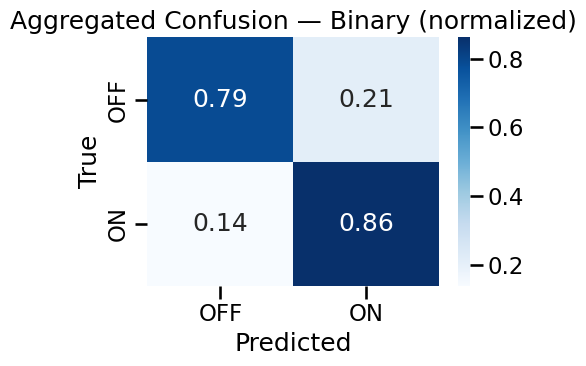


=== Aggregated Ternary (GT/fixed thresholds) ===
              precision    recall  f1-score   support

         OFF       0.82      0.97      0.89     11240
         LOW       0.42      0.22      0.29      2527
        HIGH       0.60      0.18      0.28      1125

    accuracy                           0.78     14892
   macro avg       0.61      0.46      0.49     14892
weighted avg       0.74      0.78      0.74     14892



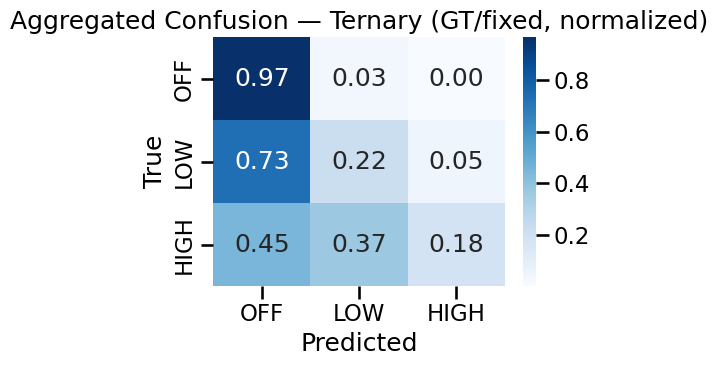


=== Aggregated Ternary (Matched-quantiles on predictions) ===
              precision    recall  f1-score   support

         OFF       0.99      0.55      0.71     11240
         LOW       0.23      0.55      0.33      2527
        HIGH       0.31      0.74      0.44      1125

    accuracy                           0.56     14892
   macro avg       0.51      0.61      0.49     14892
weighted avg       0.81      0.56      0.62     14892



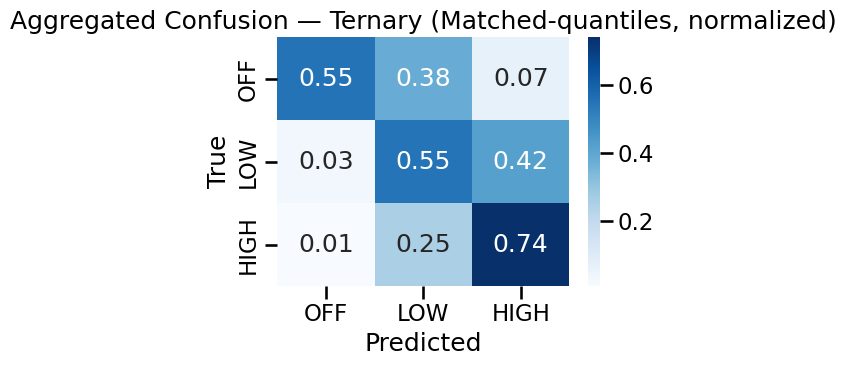

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\2311667853.py:441: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\2311667853.py:441: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\2311667853.py:441: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values



=== Aggregated Binary (ON/OFF) ===
              precision    recall  f1-score   support

         OFF       0.90      0.80      0.85      9272
          ON       0.72      0.85      0.78      5620

    accuracy                           0.82     14892
   macro avg       0.81      0.82      0.81     14892
weighted avg       0.83      0.82      0.82     14892



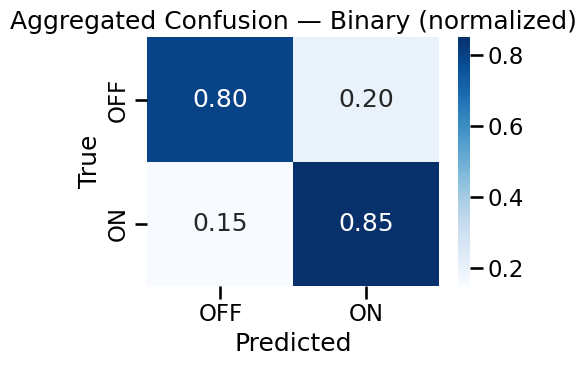


=== Aggregated Ternary (GT/fixed thresholds) ===
              precision    recall  f1-score   support

         OFF       0.86      0.94      0.90     11240
         LOW       0.45      0.40      0.43      2527
        HIGH       0.74      0.28      0.41      1125

    accuracy                           0.80     14892
   macro avg       0.68      0.54      0.58     14892
weighted avg       0.78      0.80      0.78     14892



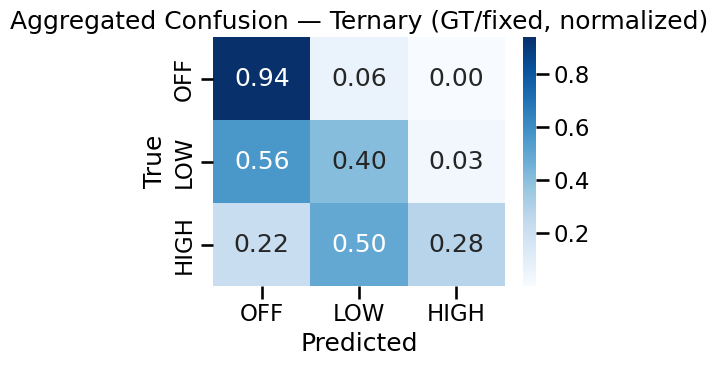


=== Aggregated Ternary (Matched-quantiles on predictions) ===
              precision    recall  f1-score   support

         OFF       0.99      0.54      0.70     11240
         LOW       0.23      0.55      0.33      2527
        HIGH       0.32      0.76      0.45      1125

    accuracy                           0.56     14892
   macro avg       0.51      0.62      0.49     14892
weighted avg       0.81      0.56      0.62     14892



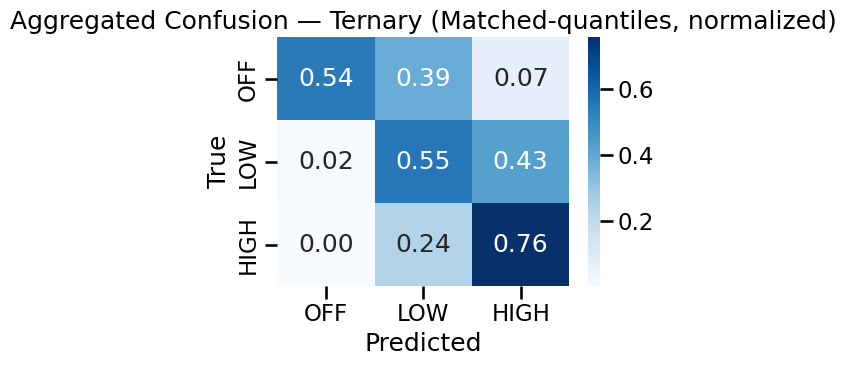

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\2311667853.py:441: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\2311667853.py:441: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\2311667853.py:441: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values



=== Aggregated Binary (ON/OFF) ===
              precision    recall  f1-score   support

         OFF       0.90      0.80      0.85      9272
          ON       0.72      0.85      0.78      5620

    accuracy                           0.82     14892
   macro avg       0.81      0.82      0.81     14892
weighted avg       0.83      0.82      0.82     14892



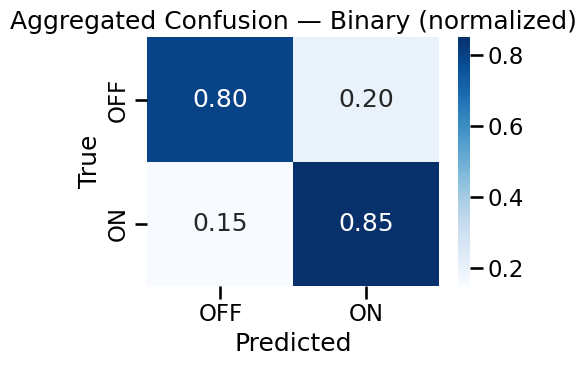


=== Aggregated Ternary (GT/fixed thresholds) ===
              precision    recall  f1-score   support

         OFF       0.86      0.94      0.90     11240
         LOW       0.45      0.40      0.43      2527
        HIGH       0.74      0.28      0.41      1125

    accuracy                           0.80     14892
   macro avg       0.68      0.54      0.58     14892
weighted avg       0.78      0.80      0.78     14892



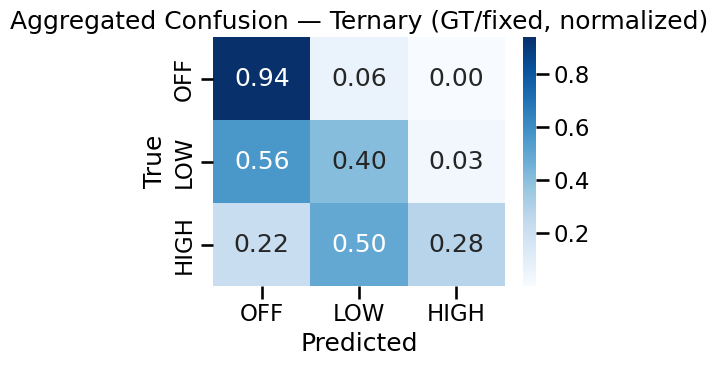


=== Aggregated Ternary (Matched-quantiles on predictions) ===
              precision    recall  f1-score   support

         OFF       0.99      0.54      0.70     11240
         LOW       0.23      0.55      0.33      2527
        HIGH       0.32      0.76      0.45      1125

    accuracy                           0.56     14892
   macro avg       0.51      0.62      0.49     14892
weighted avg       0.81      0.56      0.62     14892



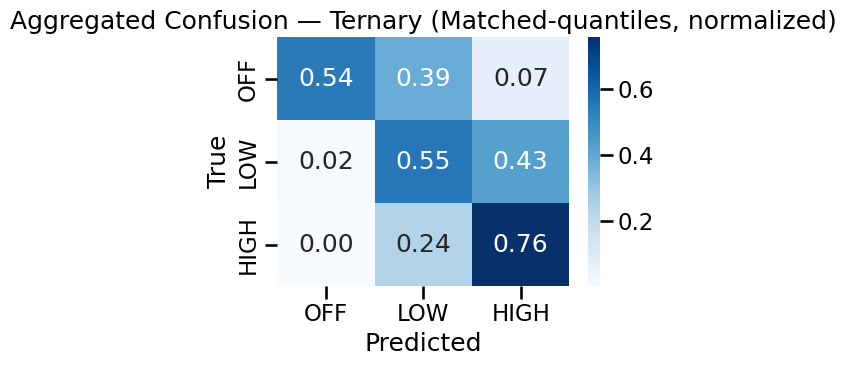

In [15]:
import torch
import os, glob, math, random, json
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import precision_recall_fscore_support, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("talk")
# -----------------------------
# 0) Config
# -----------------------------
@dataclass
class Config:
    folder: str = "datasets/retrofit/resampled"
    file_glob: str = "*with_comfort.csv"
    time_col: str = "timestamps"
    mains_col: str = "total_energy"         # aggregate
    target_cols: Tuple[str, ...] = ("pump_energy")  # pick first existing
    window: int = 13                         # must be odd (seq2point)
    batch_size: int = 256
    num_workers: int = 0
    ssl_epochs: int = 20
    ft_epochs: int = 25
    lr_ssl: float = 1e-3
    lr_ft: float = 5e-4
    weight_decay: float = 1e-5
    seed: int = 42
    n_labeled_houses: int = 3               # out of your 8
    include_labeled_in_ssl: bool = True     # often helps
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    save_dir: str = "checkpoints_ssl_s2p"
    freeze_conv_for_partial_ft: bool = True # partial vs full FT toggle
    train_val_split_days: float = 0.8       # per house split by days

cfg = Config()
if isinstance(cfg.target_cols, str):
    cfg.target_cols = (cfg.target_cols,)
# Repro
random.seed(cfg.seed); np.random.seed(cfg.seed); torch.manual_seed(cfg.seed)
os.makedirs(cfg.save_dir, exist_ok=True)

# -----------------------------
# 1) Load houses
# -----------------------------
def load_house_frames(cfg: Config) -> Dict[str, pd.DataFrame]:
    files = sorted(glob.glob(os.path.join(cfg.folder, cfg.file_glob)))
    houses = {}
    for fp in files:
        name = os.path.splitext(os.path.basename(fp))[0]
        try:
            df = pd.read_csv(fp)
            # parse time & index
            if cfg.time_col in df.columns:
                df[cfg.time_col] = pd.to_datetime(df[cfg.time_col])
                df = df.sort_values(cfg.time_col).set_index(cfg.time_col)
            else:
                # fallback: look for 'timestamp'
                if "timestamp" in df.columns:
                    df["timestamp"] = pd.to_datetime(df["timestamp"])
                    df = df.sort_values("timestamp").set_index("timestamp")
                else:
                    raise ValueError(f"No time column found in {fp}")
            # ensure numeric
            for col in [cfg.mains_col] + list(cfg.target_cols) + ["Tout", "Tin", "RH"]:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors="coerce")
            houses[name] = df
        except Exception as e:
            print(f"Skipping {fp}: {e}")
    return houses

houses = load_house_frames(cfg)
assert len(houses) >= 2, "Need at least 2 CSVs (got {})".format(len(houses))
print(f"Loaded {len(houses)} houses")

# -----------------------------
# 2) Split labeled vs unlabeled
# -----------------------------
def split_labeled_unlabeled(houses: Dict[str, pd.DataFrame],
                            n_labeled: int,
                            target_cols: Tuple[str, ...]) -> Tuple[List[str], List[str]]:
    if isinstance(target_cols, str):
        target_cols = (target_cols,)
    candidates = []
    for hid, df in houses.items():
        has_any = any(c in df.columns and pd.to_numeric(df[c], errors='coerce').fillna(0).ne(0).sum() >= 96
                      for c in target_cols)
        if has_any:
            candidates.append(hid)
    candidates.sort()  # deterministic
    labeled = candidates[:min(n_labeled, len(candidates))]
    unlabeled = [hid for hid in houses.keys() if hid not in labeled]
    return labeled, unlabeled


# -----------------------------
# 3) Normalization stats
# -----------------------------
def compute_scalers(houses: Dict[str, pd.DataFrame], ids: List[str], mains_col: str,
                    target_cols: Tuple[str, ...]) -> Dict[str, Dict[str, Tuple[float, float]]]:
    """
    Return per-house z-score (mean,std) for mains and the chosen target.
    """
    scalers = {}
    for hid in ids:
        df = houses[hid]
        mains = df[mains_col].dropna()
        tcol = next((c for c in target_cols if c in df.columns and df[c].notna().sum() > 0), None)
        target = df[tcol].dropna() if tcol else pd.Series(dtype=float)

        def mu_std(x):
            if len(x) == 0:
                return (0.0, 1.0)
            return (float(x.mean()), float(x.std() if x.std() > 1e-8 else 1.0))

        scalers[hid] = {
            "mains": mu_std(mains),
            "target": mu_std(target)
        }
    return scalers
labeled_ids, unlabeled_ids = split_labeled_unlabeled(houses, cfg.n_labeled_houses, cfg.target_cols)
print("Labeled houses:", labeled_ids)
print("Unlabeled houses:", unlabeled_ids)

# For SSL we need mains scalers for all used houses; for FT also target scaler for labeled
ssl_ids = (labeled_ids + unlabeled_ids) if cfg.include_labeled_in_ssl else unlabeled_ids
scalers = compute_scalers(houses, list(set(ssl_ids + labeled_ids)), cfg.mains_col, cfg.target_cols)

# -----------------------------
# 4) Windowing helpers
# -----------------------------
def make_windows_1d(x: np.ndarray, W: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    1D sliding windows (seq2point): input length W, label is midpoint value.
    Assumes W is odd.
    """
    assert W % 2 == 1, "Window must be odd"
    if len(x) < W: return np.empty((0, W)), np.empty((0,))
    half = W // 2
    X = np.lib.stride_tricks.sliding_window_view(x, W)  # (N-W+1, W)
    y = x[half: len(x) - half]
    return X, y

def df_to_windows_for_ssl(df: pd.DataFrame, mains_col: str, W: int,
                          mu_std_mains: Tuple[float, float]) -> Tuple[np.ndarray, np.ndarray]:
    x = df[mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
    X, y = make_windows_1d(x, W)
    mu, sd = mu_std_mains
    Xz = (X - mu) / sd
    yz = (y - mu) / sd
    return Xz, yz

def df_to_windows_for_s2p(df: pd.DataFrame, mains_col: str, target_col: str, W: int,
                          mu_std_mains: Tuple[float, float],
                          mu_std_target: Tuple[float, float]) -> Tuple[np.ndarray, np.ndarray]:
    mains = df[mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
    tgt   = df[target_col].astype(float).interpolate(limit=4).fillna(0.0).values
    X, y = make_windows_1d(mains, W)
    # align y to target midpoint
    half = W // 2
    y = tgt[half: len(tgt) - half]
    m_mu, m_sd = mu_std_mains
    t_mu, t_sd = mu_std_target
    Xz = (X - m_mu) / m_sd
    yz = (y - t_mu) / t_sd
    return Xz, yz

# -----------------------------
# 5) Datasets
# -----------------------------
class SSLWindowsDataset(Dataset):
    def __init__(self, chunks: List[Tuple[np.ndarray, np.ndarray]]):
        self.X = np.concatenate([c[0] for c in chunks], axis=0)
        self.y = np.concatenate([c[1] for c in chunks], axis=0)
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, i):
        x = torch.from_numpy(self.X[i]).float().unsqueeze(0)  # (1, W)
        y = torch.tensor(self.y[i]).float()
        return x, y

class S2PWindowsDataset(Dataset):
    def __init__(self, chunks: List[Tuple[np.ndarray, np.ndarray]]):
        self.X = np.concatenate([c[0] for c in chunks], axis=0)
        self.y = np.concatenate([c[1] for c in chunks], axis=0)
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, i):
        x = torch.from_numpy(self.X[i]).float().unsqueeze(0)
        y = torch.tensor(self.y[i]).float()
        return x, y

# -----------------------------
# 6) Train/val splits (by days)
# -----------------------------
def daywise_split_indices(idx: pd.DatetimeIndex, ratio: float):
    days = sorted(idx.normalize().unique())
    n_train = max(1, int(len(days) * ratio))
    train_days = set(days[:n_train])
    train_mask = idx.normalize().isin(train_days)
    val_mask   = ~train_mask
    return train_mask, val_mask

def build_ssl_datasets(cfg: Config, houses: Dict[str, pd.DataFrame], ssl_ids: List[str],
                       scalers: Dict[str, Dict[str, Tuple[float, float]]]) -> Tuple[Dataset, Dataset]:
    train_chunks, val_chunks = [], []
    for hid in ssl_ids:
        df = houses[hid].copy()
        if cfg.mains_col not in df.columns: continue
        tr_mask, va_mask = daywise_split_indices(df.index, cfg.train_val_split_days)
        mu_sd = scalers[hid]["mains"]
        for mask, bucket in [(tr_mask, train_chunks), (va_mask, val_chunks)]:
            part = df.loc[mask]
            if len(part) < cfg.window: continue
            Xz, yz = df_to_windows_for_ssl(part, cfg.mains_col, cfg.window, mu_sd)
            if len(Xz) > 0: bucket.append((Xz, yz))
    return SSLWindowsDataset(train_chunks), SSLWindowsDataset(val_chunks)

def pick_target_col(df: pd.DataFrame, target_cols, min_nonzero:int=96*2):
    if isinstance(target_cols, str):
        target_cols = (target_cols,)
    for c in target_cols:
        if c in df.columns:
            s = pd.to_numeric(df[c], errors="coerce").fillna(0)
            if (s != 0).sum() >= min_nonzero:   # ≥2 days of nonzero at 15-min
                return c
    return None

def build_s2p_datasets(cfg: Config, houses: Dict[str, pd.DataFrame], labeled_ids: List[str],
                       scalers: Dict[str, Dict[str, Tuple[float, float]]]) -> Tuple[Dataset, Dataset]:
    train_chunks, val_chunks = [], []
    for hid in labeled_ids:
        df = houses[hid].copy()
        tgt_col = pick_target_col(df, cfg.target_cols)
        if tgt_col is None: 
            print(f"[WARN] {hid} has no target col with data; skipping.")
            continue
        tr_mask, va_mask = daywise_split_indices(df.index, cfg.train_val_split_days)
        m_mu_sd = scalers[hid]["mains"]
        t_mu_sd = scalers[hid]["target"]
        for mask, bucket in [(tr_mask, train_chunks), (va_mask, val_chunks)]:
            part = df.loc[mask]
            if len(part) < cfg.window: continue
            Xz, yz = df_to_windows_for_s2p(part, cfg.mains_col, tgt_col, cfg.window, m_mu_sd, t_mu_sd)
            if len(Xz) > 0: bucket.append((Xz, yz))
    return S2PWindowsDataset(train_chunks), S2PWindowsDataset(val_chunks)

# -----------------------------
# 7) Seq2Point model (tiny CNN)
# -----------------------------
class Seq2Point(nn.Module):
    """
    Simple 1D CNN backbone + dense head (seq2point).
    Input: (B, 1, W)  Output: (B,)
    """
    def __init__(self, W: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 30, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(30, 30, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(30, 40, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(40, 50, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(50, 50, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.Flatten(),                                # (B, 50*W)
            nn.Linear(50*W, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(1024, 1)
        )
    def forward(self, x):
        z = self.conv(x)
        y = self.head(z)
        return y.squeeze(-1)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# -----------------------------
# 8) Train/eval loops
# -----------------------------
def train_epoch(model, loader, opt, scaler=None):
    model.train()
    total, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(cfg.device), yb.to(cfg.device)
        opt.zero_grad()
        pred = model(xb)
        loss = nn.functional.mse_loss(pred, yb)
        loss.backward()
        opt.step()
        total += loss.item() * xb.size(0); n += xb.size(0)
    return total / max(n,1)

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(cfg.device), yb.to(cfg.device)
        pred = model(xb)
        loss = nn.functional.mse_loss(pred, yb)
        total += loss.item() * xb.size(0); n += xb.size(0)
    return total / max(n,1)

def early_stop_train(model, train_loader, val_loader, epochs, lr, tag, freeze_conv=False):
    if freeze_conv:
        for p in model.conv.parameters(): p.requires_grad = False
        for p in model.head.parameters(): p.requires_grad = True
    else:
        for p in model.parameters(): p.requires_grad = True

    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=cfg.weight_decay)
    best_val, patience, patience_left = float("inf"), 5, 5
    best_path = os.path.join(cfg.save_dir, f"{tag}.pt")
    for ep in range(1, epochs+1):
        tr = train_epoch(model, train_loader, opt)
        va = eval_epoch(model, val_loader)
        print(f"[{tag}] epoch {ep:03d} | train {tr:.4f} | val {va:.4f}")
        if va + 1e-6 < best_val:
            best_val = va; patience_left = patience
            torch.save(model.state_dict(), best_path)
        else:
            patience_left -= 1
            if patience_left == 0: break
    # load best
    model.load_state_dict(torch.load(best_path, map_location=cfg.device))
    return model, best_path, best_val

# -----------------------------
# 9) Build datasets/loaders
# -----------------------------

def debug_s2p_house(hid, df, target_cols=("pump_energy","hvac_energy"), W=13):
    idx = df.index
    days = sorted(idx.normalize().unique())
    print(f"\n[DEBUG] House={hid} | rows={len(df)} | days={len(days)}")
    tcol = None
    for c in target_cols:
        if c in df.columns:
            s = pd.to_numeric(df[c], errors="coerce").fillna(0)
            nz = int((s != 0).sum())
            print(f"  col {c}: present, nonzero={nz}")
            if nz >= 2*96 and tcol is None:
                tcol = c
        else:
            print(f"  col {c}: MISSING")
    if tcol is None:
        print("  -> No suitable target column (need >= 2 days of nonzero).")
        return

    # day split that guarantees at least 1 train & 1 val day if possible
    dlen = len(days)
    if dlen >= 2:
        n_train = max(1, min(dlen-1, int(round(dlen*0.8))))
    else:
        n_train = 1
    train_days = set(days[:n_train])
    val_days   = set(days[n_train:])
    tr = df.loc[df.index.normalize().isin(train_days)]
    va = df.loc[df.index.normalize().isin(val_days)]
    print(f"  split: train_days={len(train_days)} val_days={len(val_days)} | rows train={len(tr)} val={len(va)}")

    def win_count(x):
        return max(0, len(x) - W + 1)
    print(f"  potential windows: train≈{win_count(tr)} val≈{win_count(va)}")
# for hid, df in houses.items():
#     debug_s2p_house(hid, df, target_cols=cfg.target_cols, W=cfg.window)
if isinstance(cfg.target_cols, str):
    cfg.target_cols = (cfg.target_cols,)

# Re-split houses
# labeled_ids, unlabeled_ids = split_labeled_unlabeled(houses, cfg.n_labeled_houses, cfg.target_cols)
# print("Labeled houses:", labeled_ids)
# print("Unlabeled houses:", unlabeled_ids)
# ssl_train_ds, ssl_val_ds = build_ssl_datasets(cfg, houses, ssl_ids, scalers)
# ft_train_ds , ft_val_ds  = build_s2p_datasets(cfg, houses, labeled_ids, scalers)
labeled_ids, unlabeled_ids = split_labeled_unlabeled(houses, cfg.n_labeled_houses, cfg.target_cols)
print("Labeled houses:", labeled_ids)
print("Unlabeled houses:", unlabeled_ids)

# Recompute ssl_ids and scalers to keep things consistent
ssl_ids = (labeled_ids + unlabeled_ids) if cfg.include_labeled_in_ssl else unlabeled_ids
scalers = compute_scalers(houses, list(set(ssl_ids + labeled_ids)), cfg.mains_col, cfg.target_cols)

# Build datasets/loaders
ssl_train_ds, ssl_val_ds = build_ssl_datasets(cfg, houses, ssl_ids, scalers)
ft_train_ds , ft_val_ds  = build_s2p_datasets(cfg, houses, labeled_ids, scalers)

ssl_train_ld = DataLoader(ssl_train_ds, batch_size=cfg.batch_size, shuffle=True,  num_workers=cfg.num_workers, pin_memory=True)
ssl_val_ld   = DataLoader(ssl_val_ds,   batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=True)
ft_train_ld  = DataLoader(ft_train_ds,  batch_size=cfg.batch_size, shuffle=True,  num_workers=cfg.num_workers, pin_memory=True)
ft_val_ld    = DataLoader(ft_val_ds,    batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=True)

print(f"SSL windows: train {len(ssl_train_ds):,} | val {len(ssl_val_ds):,}")
print(f"FT  windows: train {len(ft_train_ds):,} | val {len(ft_val_ds):,}")

# -----------------------------
# 10) SSL pretrain (mains→mains midpoint)
# -----------------------------
model = Seq2Point(cfg.window).to(cfg.device)
print("Model params:", count_params(model))
model, ssl_ckpt, ssl_val = early_stop_train(model, ssl_train_ld, ssl_val_ld, cfg.ssl_epochs, cfg.lr_ssl, tag="ssl_pretrain", freeze_conv=False)

# -----------------------------
# 11) Fine-tune: partial (head only) and/or full
# -----------------------------
# (a) Partial FT: freeze conv, train dense head
model.load_state_dict(torch.load(ssl_ckpt, map_location=cfg.device))
model, ft_ckpt_partial, ft_val_partial = early_stop_train(model, ft_train_ld, ft_val_ld, cfg.ft_epochs, cfg.lr_ft, tag="finetune_partial", freeze_conv=cfg.freeze_conv_for_partial_ft)

# (b) Full FT: unfreeze everything
model.load_state_dict(torch.load(ssl_ckpt, map_location=cfg.device))
model, ft_ckpt_full, ft_val_full = early_stop_train(model, ft_train_ld, ft_val_ld, cfg.ft_epochs, cfg.lr_ft, tag="finetune_full", freeze_conv=False)

print("Best val (partial):", ft_val_partial, " | Best val (full):", ft_val_full)
best_ckpt = ft_ckpt_full if ft_val_full <= ft_val_partial else ft_ckpt_partial
print("Using:", os.path.basename(best_ckpt))
model.load_state_dict(torch.load(best_ckpt, map_location=cfg.device))

# -----------------------------
# 12) Inference on unlabeled houses (mains→pump power (z), then unscale)
# -----------------------------
@torch.no_grad()
def predict_house_power(hid: str, df: pd.DataFrame, cfg: Config, scalers, model: nn.Module) -> pd.Series:
    m_mu, m_sd = scalers[hid]["mains"]
    # For output, we don't have target scaler for unlabeled homes. Use labeled target scaler median as proxy.
    # Alternatively: predict in mains-z units and map by a learned scalar. Here we borrow median target std from labeled.
    t_mean = np.median([scalers[l]["target"][0] for l in labeled_ids if "target" in scalers[l]]) if labeled_ids else 0.0
    t_std  = np.median([scalers[l]["target"][1] for l in labeled_ids if "target" in scalers[l]]) if labeled_ids else 1.0

    x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
    X, _ = make_windows_1d(x, cfg.window)
    if len(X) == 0:
        return pd.Series(index=df.index, dtype=float)

    Xz = (X - m_mu) / m_sd
    Xz_t = torch.from_numpy(Xz).float().unsqueeze(1).to(cfg.device)  # (N,1,W)
    preds_z = []
    for i in range(0, len(Xz_t), 4096):
        preds_z.append(model(Xz_t[i:i+4096]).detach().cpu().numpy())
    preds_z = np.concatenate(preds_z, axis=0)

    # Unscale using proxy target stats
    preds = preds_z * t_std + t_mean

    # Align back to timestamps (midpoints only)
    half = cfg.window // 2
    idx_mid = df.index[half: len(df) - half]
    pred_series = pd.Series(preds, index=idx_mid, name="hp_power_pred")
    return pred_series

# -----------------------------
# 13) Power→activations (0/1/2) with gating & smoothing
# -----------------------------
def power_to_modes(pred_power: pd.Series, tout: Optional[pd.Series]=None,
                   tau1=None, tau2=None,
                   min_on_slots: int = 2, min_off_slots: int = 2) -> pd.Series:
    """Quantile thresholds + small persistence smoothing; optional Tout gating."""
    pp = pred_power.fillna(0.0).clip(lower=0.0)
    if tau1 is None or tau2 is None:
        pos = pp[pp > 0]
        tau1 = np.quantile(pos, 0.35) if len(pos) else 0.0
        tau2 = np.quantile(pos, 0.80) if len(pos) else 1.0
    modes = np.zeros(len(pp), dtype=int)
    modes[(pp > tau1) & (pp < tau2)] = 1
    modes[pp >= tau2] = 2
    # mild-day gating (soft)
    if tout is not None and tout.index.equals(pp.index):
        T = tout.values
        # Calculate mild band per month (robust)
        t_low = np.nanpercentile(T, 35); t_high = np.nanpercentile(T, 85)
        mild = (T >= t_low) & (T <= t_high)
        modes[mild & (modes == 1)] = 0  # suppress weak activity on mild conditions
    # persistence smoothing
    m = modes.copy()
    # remove short bursts
    for i in range(1, len(m)-1):
        if m[i] != m[i-1] and m[i] != m[i+1]:
            m[i] = m[i-1]
    return pd.Series(m, index=pp.index, name="hvac_mode_pred")

# --- PATCH B: HMM smoothing, place after power_to_modes() ---
def modes_from_power_hmm(series: pd.Series):
    x = series.fillna(0).clip(lower=0).values.reshape(-1,1)
    try:
        from hmmlearn.hmm import GaussianHMM
        m = GaussianHMM(n_components=3, covariance_type='diag', n_iter=200, random_state=0)
        m.fit(x)
        z = m.predict(x)
        # order states by mean -> map to 0/1/2
        means = m.means_.ravel()
        order = np.argsort(means)
        remap = np.zeros_like(order)
        remap[order[0]] = 0; remap[order[1]] = 1; remap[order[2]] = 2
        # fast remap
        inv = np.empty_like(remap); inv[remap] = np.arange(3)
        z = inv[z]
    except Exception:
        # fallback: quantiles + tiny persistence
        pos = x[x>0]
        t1 = float(np.quantile(pos, 0.35)) if len(pos) else 0.0
        t2 = float(np.quantile(pos, 0.80)) if len(pos) else np.inf
        z = np.zeros(len(x), dtype=int)
        z[(x[:,0]>t1) & (x[:,0]<t2)] = 1
        z[x[:,0]>=t2] = 2
        for i in range(1,len(z)-1):
            if z[i]!=z[i-1] and z[i]!=z[i+1]:
                z[i]=z[i-1]
    return pd.Series(z, index=series.index, name="hvac_mode_hmm")

# --- PATCH C: metric helpers (after Patch B) ---
def mae(y, yhat): return float(np.mean(np.abs(y - yhat)))
def sae(y, yhat): return float(np.abs(y.sum() - yhat.sum()) / (y.sum() + 1e-9))

def energy_per_day(y, idx):
    return pd.Series(y, index=idx).resample("D").sum()

def best_onoff_threshold(y_true_power, y_pred_power, gt_eps=1e-6):
    y_true_bin = (y_true_power > gt_eps).astype(int)
    if y_true_bin.sum() == 0:
        return 0.0, {"F1": 0.0, "P": 0.0, "R": 0.0}
    preds_pos = y_pred_power[y_pred_power > 0]
    if len(preds_pos) == 0:
        return np.inf, {"F1": 0.0, "P": 0.0, "R": 0.0}
    qs = np.linspace(0.05, 0.95, 19)
    cand = np.quantile(preds_pos, qs)
    best_f1, best_tau, best_trip = -1.0, cand[0], (0,0,0)
    for tau in cand:
        y_pred_bin = (y_pred_power >= tau).astype(int)
        P, R, F1, _ = precision_recall_fscore_support(y_true_bin, y_pred_bin, average="binary", zero_division=0)
        if F1 > best_f1:
            best_f1, best_tau, best_trip = F1, tau, (P, R, F1)
    return float(best_tau), {"P": float(best_trip[0]), "R": float(best_trip[1]), "F1": float(best_trip[2])}

def ternary_thresholds_from_true(y_true_power):
    pos = y_true_power[y_true_power > 0]
    if len(pos) < 10:
        return 0.0, np.inf
    t1 = np.quantile(pos, 0.35)
    t2 = np.quantile(pos, 0.80)
    return float(t1), float(t2)

def apply_ternary(y_power, t1, t2):
    z = np.zeros_like(y_power, dtype=int)
    z[(y_power > t1) & (y_power < t2)] = 1
    z[y_power >= t2] = 2
    return z

# -----------------------------
# 14) Example: run inference & basic metrics on labeled val splits
# -----------------------------
def mae(y, yhat): return float(np.mean(np.abs(y - yhat)))
def sae(y, yhat): 
    s = np.abs(y.sum() - yhat.sum()) / (y.sum() + 1e-9)
    return float(s)
def energy_per_day(y, idx):
    d = pd.Series(y, index=idx).resample("D").sum()
    return d

# --- PATCH D: replace your old evaluation with this pro version ---
@torch.no_grad()
def evaluate_on_labeled_val_pro(cfg, houses, labeled_ids, scalers, model, use_hmm=False):
    rows = []
    details = {}
    for hid in labeled_ids:
        df = houses[hid]
        tgt_col = pick_target_col(df, cfg.target_cols, min_nonzero=96)
        if tgt_col is None: 
            print(f"[WARN] {hid}: no usable target col; skipping.")
            continue

        tr_mask, va_mask = daywise_split_indices(df.index, cfg.train_val_split_days)
        df_tr, df_va = df.loc[tr_mask], df.loc[va_mask]
        if len(df_va) < cfg.window + 2:
            print(f"[WARN] {hid}: too few val rows; skipping.")
            continue

        # Predictions on val midpoints
        pred = predict_house_power(hid, df_va, cfg, scalers, model)

        half = cfg.window // 2
        gt_mid = df_va[tgt_col].astype(float).iloc[half: len(df_va) - half]
        gt_mid = gt_mid.reindex(pred.index).fillna(0.0)

        # Power metrics
        m_mae = mae(gt_mid.values, pred.values)
        m_sae = sae(gt_mid.values, pred.values)
        epd_t = energy_per_day(gt_mid.values, gt_mid.index)
        epd_p = energy_per_day(pred.values,   pred.index)
        epd_mae = float(np.mean(np.abs(epd_t - epd_p)))

        # Baseline 0
        base0 = np.zeros_like(pred.values)
        b0_mae = mae(gt_mid.values, base0)
        b0_epd = float(np.mean(np.abs(epd_t - 0)))

        # Baseline slot-profile (from train)
        if len(df_tr) >= cfg.window + 2:
            slot_train = df_tr[tgt_col].astype(float).groupby(df_tr.index.time).mean()
            slot_val = pd.Series(index=pred.index, data=[slot_train.get(ts.time(), 0.0) for ts in pred.index])
            b1_mae = mae(gt_mid.values, slot_val.values)
            epd_slot = energy_per_day(slot_val.values, slot_val.index)
            b1_epd = float(np.mean(np.abs(epd_t - epd_slot)))
        else:
            b1_mae = np.nan; b1_epd = np.nan

        # ON/OFF metrics (threshold sweep)
        tau_on, bin_stats = best_onoff_threshold(gt_mid.values, pred.values, gt_eps=1e-6)

        # Ternary macro-F1 (match quantiles)
        t1_true, t2_true = ternary_thresholds_from_true(gt_mid.values)
        gt_tern = apply_ternary(gt_mid.values, t1_true, t2_true)
        pos_pred = pred.values[pred.values > 0]
        if len(pos_pred) >= 10:
            t1_pred = float(np.quantile(pos_pred, 0.35))
            t2_pred = float(np.quantile(pos_pred, 0.80))
        else:
            t1_pred, t2_pred = 0.0, np.inf
        pr_tern = apply_ternary(pred.values, t1_pred, t2_pred)
        f1_macro = f1_score(gt_tern, pr_tern, average="macro", zero_division=0)

        # Optional: HMM-based modes (for your eyeballing/plots)
        hmm_modes = None
        if use_hmm:
            hmm_modes = modes_from_power_hmm(pred)
            # you can compute F1 on hmm_modes vs gt_tern if you like

        rows.append({
            "house": hid,
            "MAE": m_mae,
            "SAE": m_sae,
            "EpD_MAE": epd_mae,
            "Baseline0_MAE": b0_mae,
            "Baseline0_EpD": b0_epd,
            "Profile_MAE": b1_mae,
            "Profile_EpD": b1_epd,
            "ON_best_tau": tau_on,
            "ON_P": bin_stats["P"],
            "ON_R": bin_stats["R"],
            "ON_F1": bin_stats["F1"],
            "Ternary_F1_macro": float(f1_macro),
        })

        details[hid] = {
            "val_index": gt_mid.index,
            "gt_mid": gt_mid.values,
            "pred": pred.values,
            "gt_ternary": gt_tern,
            "pred_ternary": pr_tern,
            "hmm_modes": hmm_modes.values if hmm_modes is not None else None
        }

        print(f"[{hid}] MAE={m_mae:.3f} (zeros {b0_mae:.3f} / profile {b1_mae:.3f}) | "
              f"SAE={m_sae:.3f} | EpD_MAE={epd_mae:.3f} | ON F1={bin_stats['F1']:.3f} | "
              f"Ternary macro-F1={f1_macro:.3f}")

    df_report = pd.DataFrame(rows).sort_values("MAE")
    print("\n=== Validation summary (per house) ===")
    if not df_report.empty:
        try:
            display(df_report)
        except:
            print(df_report.to_string(index=False))
        print("\nAverages:")
        print(df_report.drop(columns=["house","ON_best_tau"]).mean(numeric_only=True))
    else:
        print("No houses evaluated.")
    return df_report, details

# --- PATCH E: calibration helpers (after Patch D) ---
def calibrate_affine(gt: np.ndarray, pred: np.ndarray):
    X = np.c_[pred, np.ones_like(pred)]
    alpha, beta = np.linalg.lstsq(X, gt, rcond=None)[0]
    return float(alpha), float(beta)

@torch.no_grad()
def evaluate_on_labeled_val_with_calibration(cfg, houses, labeled_ids, scalers, model):
    rows = []
    for hid in labeled_ids:
        df = houses[hid]
        tgt_col = pick_target_col(df, cfg.target_cols, min_nonzero=96)
        if tgt_col is None: 
            continue
        tr_mask, va_mask = daywise_split_indices(df.index, cfg.train_val_split_days)
        dfv = df.loc[va_mask].copy()
        if len(dfv) < cfg.window + 2: 
            continue

        pred = predict_house_power(hid, dfv, cfg, scalers, model)
        half = cfg.window // 2
        gt_mid = dfv[tgt_col].astype(float).iloc[half: len(dfv) - half].reindex(pred.index).fillna(0.0)

        mae0 = mae(gt_mid.values, pred.values)
        sae0 = sae(gt_mid.values, pred.values)
        epd_mae0 = float(np.mean(np.abs(energy_per_day(gt_mid.values, gt_mid.index) -
                                        energy_per_day(pred.values,   pred.index))))

        alpha, beta = calibrate_affine(gt_mid.values, pred.values)
        pred_cal = alpha * pred.values + beta

        mae1 = mae(gt_mid.values, pred_cal)
        sae1 = sae(gt_mid.values, pred_cal)
        epd_mae1 = float(np.mean(np.abs(energy_per_day(gt_mid.values, gt_mid.index) -
                                        energy_per_day(pred_cal,      pred.index))))

        print(f"[{hid}] MAE {mae0:.2f}→{mae1:.2f} | SAE {sae0:.3f}→{sae1:.3f} | EpD_MAE {epd_mae0:.1f}→{epd_mae1:.1f} | α={alpha:.3f}, β={beta:.3f}")
        rows.append({"house":hid,"MAE_before":mae0,"MAE_after":mae1,"SAE_before":sae0,"SAE_after":sae1,
                     "EpD_before":epd_mae0,"EpD_after":epd_mae1,"alpha":alpha,"beta":beta})
    return pd.DataFrame(rows)

# --- PATCH F: 10-day plot helper (after Patch E) ---
def plot_10_days(details, hid, start_date=None):
    d = details[hid]
    idx = pd.DatetimeIndex(d["val_index"])
    gt = pd.Series(d["gt_mid"], index=idx)
    pr = pd.Series(d["pred"],   index=idx)

    if start_date is None:
        start_date = idx.normalize()[0]
    start = pd.Timestamp(start_date); end = start + pd.Timedelta(days=10)

    gt10 = gt.loc[start:end]; pr10 = pr.loc[start:end]
    if len(gt10) == 0:
        print("No data in selected 10-day window."); return

    plt.figure(figsize=(18,4))
    plt.plot(gt10.index, gt10.values, label="GT pump", linewidth=2)
    plt.plot(pr10.index, pr10.values, label="Pred pump", linewidth=1.5, alpha=0.85)
    plt.title(f"{hid} — pump power (GT vs Pred), {start.date()} to {end.date()}")
    plt.ylabel("Power"); plt.xlabel("Time")
    plt.grid(True, linestyle="--", alpha=0.4); plt.legend(); plt.tight_layout(); plt.show()

val_report, details = evaluate_on_labeled_val_pro(cfg, houses, labeled_ids, scalers, model, use_hmm=False)

# (Optional) Calibration analysis on the same val split
calib_table = evaluate_on_labeled_val_with_calibration(cfg, houses, labeled_ids, scalers, model)
def _plot_cm(cm, labels, title, normalize=True, figsize=(5,4), save_path=None):
    cm_plot = cm.astype(float)
    if normalize:
        with np.errstate(invalid='ignore'):
            cm_plot = cm_plot / np.clip(cm_plot.sum(axis=1, keepdims=True), 1, None)
    plt.figure(figsize=figsize)
    sns.heatmap(cm_plot, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=200)
    plt.show()

@torch.no_grad()
def confusion_eval_seq2point(cfg, houses, labeled_ids, scalers, model,
                             use_calibration=False,
                             t1_fixed=None, t2_fixed=None,
                             plot_per_house=False, save_dir="results_eval"):
    """
    Confusion matrices on VALIDATION split of labeled houses.

    Options:
      - use_calibration: fit α,β on each house's val set (GT vs pred), apply before thresholding
      - t1_fixed, t2_fixed: if provided, use fixed absolute thresholds for ternary on BOTH GT and preds.
                            (e.g., set t2_fixed=60 to match your unsupervised 'high_thresh')
      - plot_per_house: also plot per-house CMs
    Saves aggregated CM PNGs under save_dir.
    """
    os.makedirs(save_dir, exist_ok=True)

    labels_bin = [0, 1]
    labels_ter = [0, 1, 2]
    names_ter  = ["OFF","LOW","HIGH"]

    cm_bin_sum    = np.zeros((2,2), dtype=int)
    cm_ter_gt_sum = np.zeros((3,3), dtype=int)
    cm_ter_mq_sum = np.zeros((3,3), dtype=int)

    agg_true_bin, agg_pred_bin = [], []
    agg_true_ter, agg_pred_ter_gt, agg_pred_ter_mq = [], [], []

    for hid in labeled_ids:
        df = houses[hid]
        tgt_col = pick_target_col(df, cfg.target_cols, min_nonzero=96)
        if tgt_col is None:
            print(f"[WARN] {hid}: no usable target; skipping."); continue

        tr_mask, va_mask = daywise_split_indices(df.index, cfg.train_val_split_days)
        dfv = df.loc[va_mask].copy()
        if len(dfv) < cfg.window + 2:
            print(f"[WARN] {hid}: too few val rows; skipping."); continue

        # predictions at midpoints
        pred = predict_house_power(hid, dfv, cfg, scalers, model)
        half = cfg.window // 2
        gt_mid = dfv[tgt_col].astype(float).iloc[half: len(dfv) - half].reindex(pred.index).fillna(0.0)

        y_true_power = gt_mid.values
        y_pred_power = pred.values

        # optional per-house calibration on val
        if use_calibration:
            X = np.c_[y_pred_power, np.ones_like(y_pred_power)]
            alpha, beta = np.linalg.lstsq(X, y_true_power, rcond=None)[0]
            y_pred_power = alpha * y_pred_power + beta

        # ---------- Binary ----------
        tau_on, _ = best_onoff_threshold(y_true_power, y_pred_power, gt_eps=1e-6)
        y_true_bin = (y_true_power > 1e-6).astype(int)
        y_pred_bin = (y_pred_power >= tau_on).astype(int)

        cm_bin = confusion_matrix(y_true_bin, y_pred_bin, labels=labels_bin)
        cm_bin_sum += cm_bin
        agg_true_bin.append(y_true_bin); agg_pred_bin.append(y_pred_bin)

        if plot_per_house:
            _plot_cm(cm_bin, ["OFF","ON"], f"[{hid}] Binary ON/OFF (best τ={tau_on:.2f})",
                     normalize=True, save_path=os.path.join(save_dir, f"{hid}_cm_binary.png"))

        # ---------- Ternary (A) GT-anchored or fixed thresholds ----------
        if t1_fixed is not None and t2_fixed is not None:
            t1_true, t2_true = float(t1_fixed), float(t2_fixed)
        else:
            t1_true, t2_true = ternary_thresholds_from_true(y_true_power)
        y_true_ter = apply_ternary(y_true_power, t1_true, t2_true)
        y_pred_ter_gt = apply_ternary(y_pred_power, t1_true, t2_true)
        cm_ter_gt = confusion_matrix(y_true_ter, y_pred_ter_gt, labels=labels_ter)
        cm_ter_gt_sum += cm_ter_gt

        # ---------- Ternary (B) Matched-quantiles on predictions ----------
        pos_pred = y_pred_power[y_pred_power > 0]
        if len(pos_pred) >= 10:
            t1_pred = float(np.quantile(pos_pred, 0.35))
            t2_pred = float(np.quantile(pos_pred, 0.80))
        else:
            t1_pred, t2_pred = 0.0, np.inf
        y_pred_ter_mq = apply_ternary(y_pred_power, t1_pred, t2_pred)
        cm_ter_mq = confusion_matrix(y_true_ter, y_pred_ter_mq, labels=labels_ter)
        cm_ter_mq_sum += cm_ter_mq

        if plot_per_house:
            titleA = f"[{hid}] Ternary (GT/fixed: t1={t1_true:.1f}, t2={t2_true:.1f})"
            _plot_cm(cm_ter_gt, names_ter, titleA, normalize=True,
                     save_path=os.path.join(save_dir, f"{hid}_cm_ternary_GT.png"))
            _plot_cm(cm_ter_mq, names_ter, f"[{hid}] Ternary (Matched-quantiles on preds)", normalize=True,
                     save_path=os.path.join(save_dir, f"{hid}_cm_ternary_MQ.png"))

        agg_true_ter.append(y_true_ter)
        agg_pred_ter_gt.append(y_pred_ter_gt)
        agg_pred_ter_mq.append(y_pred_ter_mq)

    # ---------- Aggregated reports ----------
    if agg_true_bin:
        ytb = np.concatenate(agg_true_bin); ypb = np.concatenate(agg_pred_bin)
        print("\n=== Aggregated Binary (ON/OFF) ===")
        print(classification_report(ytb, ypb, labels=[0,1], target_names=["OFF","ON"], zero_division=0))
        _plot_cm(cm_bin_sum, ["OFF","ON"], "Aggregated Confusion — Binary (normalized)", normalize=True,
                 save_path=os.path.join(save_dir, "agg_cm_binary.png"))

    if agg_true_ter:
        yt = np.concatenate(agg_true_ter)
        yp_gt = np.concatenate(agg_pred_ter_gt)
        yp_mq = np.concatenate(agg_pred_ter_mq)

        print("\n=== Aggregated Ternary (GT/fixed thresholds) ===")
        print(classification_report(yt, yp_gt, labels=[0,1,2], target_names=["OFF","LOW","HIGH"], zero_division=0))
        _plot_cm(cm_ter_gt_sum, ["OFF","LOW","HIGH"], "Aggregated Confusion — Ternary (GT/fixed, normalized)", normalize=True,
                 save_path=os.path.join(save_dir, "agg_cm_ternary_GT.png"))

        print("\n=== Aggregated Ternary (Matched-quantiles on predictions) ===")
        print(classification_report(yt, yp_mq, labels=[0,1,2], target_names=["OFF","LOW","HIGH"], zero_division=0))
        _plot_cm(cm_ter_mq_sum, ["OFF","LOW","HIGH"], "Aggregated Confusion — Ternary (Matched-quantiles, normalized)", normalize=True,
                 save_path=os.path.join(save_dir, "agg_cm_ternary_MQ.png"))
# (Optional) Nice Markdown export so you can paste here cleanly
try:
    from tabulate import tabulate
    print(tabulate(val_report.round(3).values.tolist(),
                   headers=val_report.columns.tolist(), tablefmt="github"))
except:
    pass

# (Optional) Plot 10 consecutive days for the best MAE house
if not val_report.empty:
    hid0 = val_report.iloc[0]["house"]
    plot_10_days(details, hid0, start_date="2023-02-01")

cmsA = confusion_eval_seq2point(cfg, houses, labeled_ids, scalers, model,
                                use_calibration=False,
                                t1_fixed=None, t2_fixed=None,
                                plot_per_house=False, save_dir="results_eval")

# B) With per-house calibration on val, GT-anchored thresholds:
cmsB = confusion_eval_seq2point(cfg, houses, labeled_ids, scalers, model,
                                use_calibration=True,
                                t1_fixed=None, t2_fixed=None,
                                plot_per_house=False, save_dir="results_eval_calibrated")

# C) With calibration, FIXED high threshold to mirror your unsupervised (e.g. 60):
#    (Set t1_fixed to your chosen low cut; if you don't have one, leave None to use GT q35 for both)
cmsC = confusion_eval_seq2point(cfg, houses, labeled_ids, scalers, model,
                                use_calibration=True,
                                t1_fixed=None, t2_fixed=60.0,   # <-- match your unsupervised 'high_thresh'
                                plot_per_house=False, save_dir="results_eval_calibrated_fixed60")

In [5]:
from sklearn.metrics import precision_recall_fscore_support, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("talk")

def mae(y, yhat): return float(np.mean(np.abs(y - yhat)))
def sae(y, yhat): return float(np.abs(y.sum() - yhat.sum()) / (y.sum() + 1e-9))

def energy_per_day(y, idx):
    return pd.Series(y, index=idx).resample("D").sum()

def best_onoff_threshold(y_true_power, y_pred_power, gt_eps=1e-6):
    """
    Choose the prediction threshold that maximizes F1 for ON/OFF.
    GT ON = y_true_power > gt_eps.
    """
    y_true_bin = (y_true_power > gt_eps).astype(int)
    if y_true_bin.sum() == 0:
        return 0.0, {"F1": 0.0, "P": 0.0, "R": 0.0}
    # sweep candidate thresholds on predicted power quantiles
    preds_pos = y_pred_power[y_pred_power > 0]
    if len(preds_pos) == 0:
        return np.inf, {"F1": 0.0, "P": 0.0, "R": 0.0}
    qs = np.linspace(0.05, 0.95, 19)
    cand = np.quantile(preds_pos, qs)
    best_f1, best_tau, best_trip = -1.0, cand[0], (0,0,0)
    for tau in cand:
        y_pred_bin = (y_pred_power >= tau).astype(int)
        P, R, F1, _ = precision_recall_fscore_support(y_true_bin, y_pred_bin, average="binary", zero_division=0)
        if F1 > best_f1:
            best_f1, best_tau, best_trip = F1, tau, (P, R, F1)
    return float(best_tau), {"P": float(best_trip[0]), "R": float(best_trip[1]), "F1": float(best_trip[2])}

def ternary_thresholds_from_true(y_true_power):
    """Get low/high cutoffs from GT nonzero distribution (robust)."""
    pos = y_true_power[y_true_power > 0]
    if len(pos) < 10:
        return 0.0, np.inf  # degenerate
    t1 = np.quantile(pos, 0.35)
    t2 = np.quantile(pos, 0.80)
    return float(t1), float(t2)

def apply_ternary(y_power, t1, t2):
    z = np.zeros_like(y_power, dtype=int)
    z[(y_power > t1) & (y_power < t2)] = 1
    z[y_power >= t2] = 2
    return z

@torch.no_grad()
def evaluate_on_labeled_val_pro(cfg, houses, labeled_ids, scalers, model):
    rows = []
    details = {}
    for hid in labeled_ids:
        df = houses[hid]
        tgt_col = pick_target_col(df, cfg.target_cols, min_nonzero=96)  # ≥1 day of activity
        if tgt_col is None: 
            print(f"[WARN] {hid}: no usable target col; skipping.")
            continue

        # Split by days
        tr_mask, va_mask = daywise_split_indices(df.index, cfg.train_val_split_days)
        df_tr, df_va = df.loc[tr_mask], df.loc[va_mask]
        if len(df_va) < cfg.window + 2:
            print(f"[WARN] {hid}: too few val rows; skipping.")
            continue

        # Predictions on val (midpoint index)
        pred = predict_house_power(hid, df_va, cfg, scalers, model)

        # Align GT (midpoints)
        half = cfg.window // 2
        gt_mid = df_va[tgt_col].astype(float).iloc[half: len(df_va) - half]
        gt_mid = gt_mid.reindex(pred.index).fillna(0.0)

        # --- Power metrics
        m_mae = mae(gt_mid.values, pred.values)
        m_sae = sae(gt_mid.values, pred.values)
        epd_t = energy_per_day(gt_mid.values, gt_mid.index)
        epd_p = energy_per_day(pred.values,   pred.index)
        epd_mae = float(np.mean(np.abs(epd_t - epd_p)))

        # --- Baselines
        # (a) zeros baseline
        base0 = np.zeros_like(pred.values)
        b0_mae = mae(gt_mid.values, base0)
        b0_epd = float(np.mean(np.abs(epd_t - 0)))

        # (b) slot profile from TRAIN days
        if len(df_tr) >= cfg.window + 2:
            # mean true power per slot from train → apply to val midpoints
            slot_train = df_tr[tgt_col].astype(float).groupby(df_tr.index.time).mean()
            slot_val = pd.Series(index=pred.index, data=[slot_train.get(ts.time(), 0.0) for ts in pred.index])
            b1_mae = mae(gt_mid.values, slot_val.values)
            epd_slot = energy_per_day(slot_val.values, slot_val.index)
            b1_epd = float(np.mean(np.abs(epd_t - epd_slot)))
        else:
            b1_mae = np.nan; b1_epd = np.nan

        # --- ON/OFF
        tau_on, bin_stats = best_onoff_threshold(gt_mid.values, pred.values, gt_eps=1e-6)

        # --- Ternary (0/1/2)
        t1_true, t2_true = ternary_thresholds_from_true(gt_mid.values)
        gt_tern = apply_ternary(gt_mid.values, t1_true, t2_true)

        # To keep class balance, set pred thresholds at **same quantiles** of pred positives
        pos_pred = pred.values[pred.values > 0]
        if len(pos_pred) >= 10:
            t1_pred = float(np.quantile(pos_pred, 0.35))
            t2_pred = float(np.quantile(pos_pred, 0.80))
        else:
            t1_pred, t2_pred = 0.0, np.inf
        pr_tern = apply_ternary(pred.values, t1_pred, t2_pred)

        f1_macro = f1_score(gt_tern, pr_tern, average="macro", zero_division=0)

        rows.append({
            "house": hid,
            "MAE": m_mae,
            "SAE": m_sae,
            "EpD_MAE": epd_mae,
            "Baseline0_MAE": b0_mae,
            "Baseline0_EpD": b0_epd,
            "Profile_MAE": b1_mae,
            "Profile_EpD": b1_epd,
            "ON_best_tau": tau_on,
            "ON_P": bin_stats["P"],
            "ON_R": bin_stats["R"],
            "ON_F1": bin_stats["F1"],
            "Ternary_F1_macro": float(f1_macro),
        })

        details[hid] = {
            "val_index": gt_mid.index,
            "gt_mid": gt_mid.values,
            "pred": pred.values,
            "gt_ternary": gt_tern,
            "pred_ternary": pr_tern
        }

        print(f"[{hid}] MAE={m_mae:.3f} (zeros {b0_mae:.3f} / profile {b1_mae:.3f}) | "
              f"SAE={m_sae:.3f} | EpD_MAE={epd_mae:.3f} | ON F1={bin_stats['F1']:.3f} | "
              f"Ternary macro-F1={f1_macro:.3f}")

    df_report = pd.DataFrame(rows).sort_values("MAE")
    print("\n=== Validation summary (per house) ===")
    if not df_report.empty:
        display(df_report)
        print("\nAverages:")
        print(df_report.drop(columns=["house","ON_best_tau"]).mean(numeric_only=True))
    else:
        print("No houses evaluated.")
    return df_report, details

val_report, details = evaluate_on_labeled_val_pro(cfg, houses, labeled_ids, scalers, model)


[resampled_0_with_comfort] MAE=12.451 (zeros 15.690 / profile 25.425) | SAE=0.423 | EpD_MAE=669.226 | ON F1=0.811 | Ternary macro-F1=0.336
[resampled_1_with_comfort] MAE=45.819 (zeros 61.670 / profile 59.560) | SAE=0.463 | EpD_MAE=4012.044 | ON F1=0.809 | Ternary macro-F1=0.608
[resampled_2_with_comfort] MAE=21.664 (zeros 24.379 / profile 32.522) | SAE=0.052 | EpD_MAE=893.352 | ON F1=0.721 | Ternary macro-F1=0.432

=== Validation summary (per house) ===


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\1925974841.py:427: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\1925974841.py:427: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\1925974841.py:427: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values


,house,MAE,SAE,EpD_MAE,Baseline0_MAE,Baseline0_EpD,Profile_MAE,Profile_EpD,ON_best_tau,ON_P,ON_R,ON_F1,Ternary_F1_macro
0,resampled_0_with_comfort,12.451043,0.422754,669.225967,15.690085,1497.799619,25.425381,1297.541458,23.779058,0.779156,0.845601,0.811020,0.335776
2,resampled_2_with_comfort,21.663730,0.052294,893.352271,24.379227,2327.278556,32.521780,1858.534642,16.707997,0.622174,0.856886,0.720907,0.432326
1,resampled_1_with_comfort,45.818869,0.462502,4012.044109,61.670017,5887.114688,59.560110,4319.931343,14.874681,0.755814,0.870945,0.809305,0.607632



Averages:
MAE                   26.644547
SAE                    0.312517
EpD_MAE             1858.207449
Baseline0_MAE         33.913110
Baseline0_EpD       3237.397621
Profile_MAE           39.169090
Profile_EpD         2492.002481
ON_P                   0.719048
ON_R                   0.857811
ON_F1                  0.780411
Ternary_F1_macro       0.458578
dtype: float64


In [6]:
md = val_report.round(3).to_markdown(index=False, tablefmt="github")
with open("val_report.md", "w", encoding="utf-8") as f:
    f.write(md)
print(md)

cols = ["house","MAE","SAE","EpD_MAE","ON_F1","Ternary_F1_macro"]
md = (val_report[cols]
      .sort_values("MAE")
      .round(3)
      .rename(columns={"ON_F1":"ON_F1","Ternary_F1_macro":"F1_macro_0/1/2"})
      .to_markdown(index=False, tablefmt="github"))
print(md)

from tabulate import tabulate
print(tabulate(val_report.round(3).values.tolist(),
               headers=val_report.columns.tolist(),
               tablefmt="psql"))

| house                    |    MAE |   SAE |   EpD_MAE |   Baseline0_MAE |   Baseline0_EpD |   Profile_MAE |   Profile_EpD |   ON_best_tau |   ON_P |   ON_R |   ON_F1 |   Ternary_F1_macro |
|--------------------------|--------|-------|-----------|-----------------|-----------------|---------------|---------------|---------------|--------|--------|---------|--------------------|
| resampled_0_with_comfort | 12.451 | 0.423 |   669.226 |          15.69  |         1497.8  |        25.425 |       1297.54 |        23.779 |  0.779 |  0.846 |   0.811 |              0.336 |
| resampled_2_with_comfort | 21.664 | 0.052 |   893.352 |          24.379 |         2327.28 |        32.522 |       1858.54 |        16.708 |  0.622 |  0.857 |   0.721 |              0.432 |
| resampled_1_with_comfort | 45.819 | 0.463 |  4012.04  |          61.67  |         5887.11 |        59.56  |       4319.93 |        14.875 |  0.756 |  0.871 |   0.809 |              0.608 |
| house                    |    MAE |   SAE |

In [8]:
import os
os.makedirs("results_unlabeled", exist_ok=True)

# If you ran the calibration table on labeled houses, borrow median alpha/beta
alpha_med, beta_med = 1.0, 0.0
try:
    if not calib_table.empty:
        alpha_med = float(calib_table["alpha"].median())
        beta_med  = float(calib_table["beta"].median())
        print(f"Using median calibration from labeled houses: α={alpha_med:.3f}, β={beta_med:.3f}")
except NameError:
    pass  # calib_table not computed; keep identity calibration

@torch.no_grad()
def infer_unlabeled_house(hid):
    df = houses[hid].copy()
    pred = predict_house_power(hid, df, cfg, scalers, model)  # midpoint-indexed series
    # apply global (median) calibration if available
    pred_cal = alpha_med * pred + beta_med
    modes = modes_from_power_hmm(pred_cal)

    # join back to full index for easy plotting/export
    out = pd.DataFrame(index=df.index)
    out["hp_power_pred"] = pred_cal.reindex(out.index)
    out["hvac_mode_pred"] = modes.reindex(out.index)

    # quick proxies (since we have no GT)
    epd_pred = out["hp_power_pred"].fillna(0).resample("D").sum()
    on_ratio = (out["hvac_mode_pred"] > 0).mean()

    corr_hdd = np.nan
    if "Tout" in df.columns:
        daily_T = df["Tout"].resample("D").mean()
        # simple HDD base (e.g., 18°C) — adjust if cooling-dominated
        HDD = (18 - daily_T).clip(lower=0)
        if len(HDD.dropna()) and len(epd_pred.dropna()):
            c = np.corrcoef(HDD.loc[epd_pred.index].fillna(0), epd_pred.fillna(0))[0,1]
            corr_hdd = float(c)

    print(f"[{hid}] days={epd_pred.shape[0]} | PredEnergy/day median={epd_pred.median():.2f} | "
          f"ON%={on_ratio:.2%} | Corr(E/day, HDD)={corr_hdd:.3f}")

    # export CSV
    out.to_csv(f"results_unlabeled/{hid}_preds.csv")
    return out

# run for all unlabeled
for hid in unlabeled_ids:
    infer_unlabeled_house(hid)

Using median calibration from labeled houses: α=0.958, β=0.706


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\3857970562.py:430: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Kelsier\.conda\envs\thesis\Lib\subprocess.py", line 550, in run


[resampled_3_with_comfort] days=260 | PredEnergy/day median=2645.33 | ON%=66.12% | Corr(E/day, HDD)=0.869


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\3857970562.py:430: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values


[resampled_4_with_comfort] days=260 | PredEnergy/day median=2772.28 | ON%=74.48% | Corr(E/day, HDD)=0.385


...

[resampled_5_with_comfort] days=260 | PredEnergy/day median=3396.35 | ON%=70.27% | Corr(E/day, HDD)=0.849


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\3857970562.py:430: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values


[resampled_6_with_comfort] days=260 | PredEnergy/day median=1671.36 | ON%=68.43% | Corr(E/day, HDD)=0.316


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\3857970562.py:430: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values


[resampled_7_with_comfort] days=260 | PredEnergy/day median=2740.13 | ON%=79.41% | Corr(E/day, HDD)=0.810


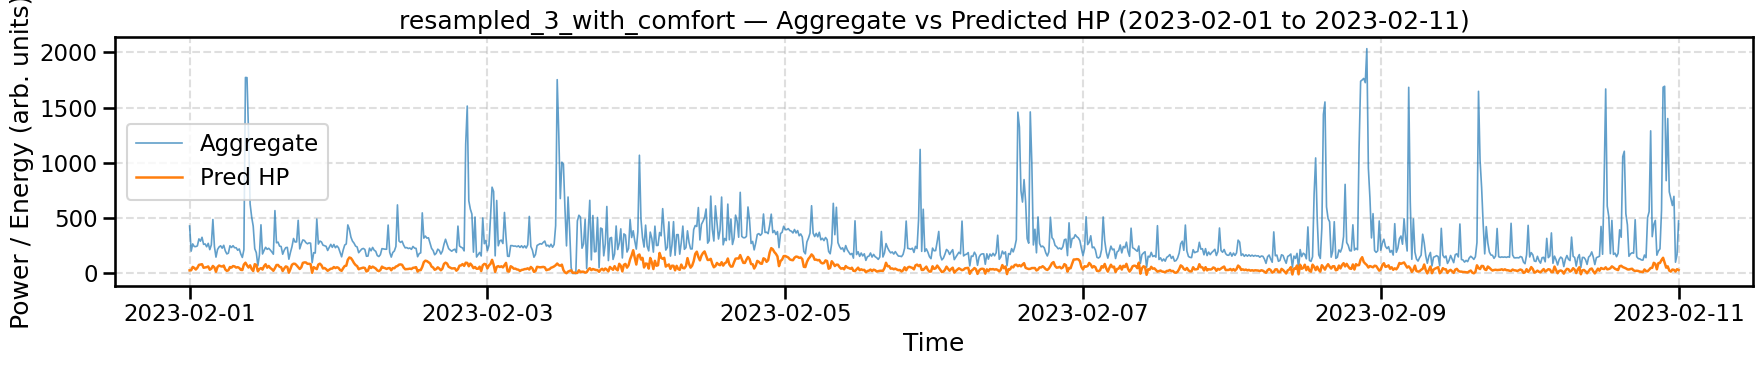

In [10]:
def plot_unlabeled_10d(hid, start_date="2023-02-01"):
    df = houses[hid]
    preds = pd.read_csv(f"results_unlabeled/{hid}_preds.csv", index_col=0, parse_dates=True)
    start = pd.Timestamp(start_date); end = start + pd.Timedelta(days=10)
    mains = df[cfg.mains_col].loc[start:end]
    hp    = preds["hp_power_pred"].loc[start:end]

    import matplotlib.pyplot as plt
    plt.figure(figsize=(18,4))
    plt.plot(mains.index, mains.values, label="Aggregate", linewidth=1.2, alpha=0.7)
    plt.plot(hp.index,    hp.values,    label="Pred HP",  linewidth=1.8)
    plt.title(f"{hid} — Aggregate vs Predicted HP ({start.date()} to {end.date()})")
    plt.ylabel("Power / Energy (arb. units)"); plt.xlabel("Time")
    plt.grid(True, linestyle="--", alpha=0.4); plt.legend(); plt.tight_layout(); plt.show()

plot_unlabeled_10d(unlabeled_ids[0], start_date="2023-02-01")


In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def _plot_cm(cm, labels, title, normalize=True, figsize=(5,4), save_path=None):
    cm_plot = cm.astype(float)
    if normalize:
        cm_plot = cm_plot / np.clip(cm_plot.sum(axis=1, keepdims=True), 1, None)
    plt.figure(figsize=figsize)
    sns.heatmap(cm_plot, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=200)
    plt.show()

@torch.no_grad()
def confusion_eval_seq2point(cfg, houses, labeled_ids, scalers, model,
                             plot_per_house=False, save_dir=None):
    """
    Builds confusion matrices on the VALIDATION split of labeled houses.
    - Binary (ON/OFF): threshold chosen to maximize F1 on each house.
    - Ternary (0/1/2): two views
        (A) GT-anchored thresholds: apply GT low/high cutoffs to both GT and predictions
        (B) Matched-quantiles: use 35%/80% quantiles separately on predictions
    Returns dict with aggregated matrices & classification reports.
    """
    os.makedirs(save_dir or ".", exist_ok=True)
    labels_bin = [0, 1]
    labels_ter = [0, 1, 2]
    names_ter  = ["OFF","LOW","HIGH"]

    agg_true_bin, agg_pred_bin = [], []
    agg_true_ter, agg_pred_ter_gt, agg_pred_ter_mq = [], [], []

    # also accumulate summed confusion matrices across houses
    cm_bin_sum    = np.zeros((2,2), dtype=int)
    cm_ter_gt_sum = np.zeros((3,3), dtype=int)
    cm_ter_mq_sum = np.zeros((3,3), dtype=int)

    for hid in labeled_ids:
        df = houses[hid]
        tgt_col = pick_target_col(df, cfg.target_cols, min_nonzero=96)
        if tgt_col is None:
            print(f"[WARN] {hid}: no usable target; skipping.")
            continue

        # validation split
        tr_mask, va_mask = daywise_split_indices(df.index, cfg.train_val_split_days)
        dfv = df.loc[va_mask].copy()
        if len(dfv) < cfg.window + 2:
            print(f"[WARN] {hid}: too few val rows; skipping.")
            continue

        # predictions at midpoints
        pred = predict_house_power(hid, dfv, cfg, scalers, model)
        half = cfg.window // 2
        gt_mid = dfv[tgt_col].astype(float).iloc[half: len(dfv) - half].reindex(pred.index).fillna(0.0)

        y_true_power = gt_mid.values
        y_pred_power = pred.values

        # ---------- Binary ----------
        tau_on, _ = best_onoff_threshold(y_true_power, y_pred_power, gt_eps=1e-6)
        y_true_bin = (y_true_power > 1e-6).astype(int)
        y_pred_bin = (y_pred_power >= tau_on).astype(int)

        cm_bin = confusion_matrix(y_true_bin, y_pred_bin, labels=labels_bin)
        cm_bin_sum += cm_bin
        agg_true_bin.append(y_true_bin)
        agg_pred_bin.append(y_pred_bin)

        if plot_per_house:
            _plot_cm(cm_bin, ["OFF","ON"], f"[{hid}] Binary ON/OFF (best τ={tau_on:.2f})",
                     normalize=True, save_path=(f"{save_dir}/{hid}_cm_binary.png" if save_dir else None))

        # ---------- Ternary (A) GT-anchored absolute thresholds ----------
        t1_true, t2_true = ternary_thresholds_from_true(y_true_power)  # from GT distribution
        y_true_ter = apply_ternary(y_true_power, t1_true, t2_true)
        y_pred_ter_gt = apply_ternary(y_pred_power, t1_true, t2_true)

        cm_ter_gt = confusion_matrix(y_true_ter, y_pred_ter_gt, labels=labels_ter)
        cm_ter_gt_sum += cm_ter_gt

        # ---------- Ternary (B) Matched-quantiles on predictions ----------
        pos_pred = y_pred_power[y_pred_power > 0]
        if len(pos_pred) >= 10:
            t1_pred = float(np.quantile(pos_pred, 0.35))
            t2_pred = float(np.quantile(pos_pred, 0.80))
        else:
            t1_pred, t2_pred = 0.0, np.inf
        y_pred_ter_mq = apply_ternary(y_pred_power, t1_pred, t2_pred)
        cm_ter_mq = confusion_matrix(y_true_ter, y_pred_ter_mq, labels=labels_ter)
        cm_ter_mq_sum += cm_ter_mq

        if plot_per_house:
            _plot_cm(cm_ter_gt, names_ter, f"[{hid}] Ternary (GT-anchored: t1={t1_true:.1f}, t2={t2_true:.1f})",
                     normalize=True, save_path=(f"{save_dir}/{hid}_cm_ternary_GT.png" if save_dir else None))
            _plot_cm(cm_ter_mq, names_ter, f"[{hid}] Ternary (Matched-quantiles on preds)",
                     normalize=True, save_path=(f"{save_dir}/{hid}_cm_ternary_MQ.png" if save_dir else None))

        # aggregate lists for macro reports
        agg_true_ter.append(y_true_ter)
        agg_pred_ter_gt.append(y_pred_ter_gt)
        agg_pred_ter_mq.append(y_pred_ter_mq)

    # ---------- Aggregated reports ----------
    out = {}

    if agg_true_bin:
        ytb = np.concatenate(agg_true_bin); ypb = np.concatenate(agg_pred_bin)
        print("\n=== Aggregated Binary (ON/OFF) ===")
        print(classification_report(ytb, ypb, labels=[0,1], target_names=["OFF","ON"], zero_division=0))
        _plot_cm(cm_bin_sum, ["OFF","ON"], "Aggregated Confusion — Binary (normalized)", normalize=True,
                 save_path=(f"{save_dir}/agg_cm_binary.png" if save_dir else None))
        out["cm_binary_sum"] = cm_bin_sum
        out["bin_report"] = classification_report(ytb, ypb, labels=[0,1],
                                                  target_names=["OFF","ON"], zero_division=0, output_dict=True)

    if agg_true_ter:
        yt = np.concatenate(agg_true_ter)
        yp_gt = np.concatenate(agg_pred_ter_gt)
        yp_mq = np.concatenate(agg_pred_ter_mq)

        print("\n=== Aggregated Ternary (GT-anchored thresholds) ===")
        print(classification_report(yt, yp_gt, labels=[0,1,2], target_names=["OFF","LOW","HIGH"], zero_division=0))
        _plot_cm(cm_ter_gt_sum, ["OFF","LOW","HIGH"],
                 "Aggregated Confusion — Ternary (GT-anchored, normalized)", normalize=True,
                 save_path=(f"{save_dir}/agg_cm_ternary_GT.png" if save_dir else None))

        print("\n=== Aggregated Ternary (Matched-quantiles on predictions) ===")
        print(classification_report(yt, yp_mq, labels=[0,1,2], target_names=["OFF","LOW","HIGH"], zero_division=0))
        _plot_cm(cm_ter_mq_sum, ["OFF","LOW","HIGH"],
                 "Aggregated Confusion — Ternary (Matched-quantiles, normalized)", normalize=True,
                 save_path=(f"{save_dir}/agg_cm_ternary_MQ.png" if save_dir else None))

        out["cm_ternary_sum_GT"] = cm_ter_gt_sum
        out["cm_ternary_sum_MQ"] = cm_ter_mq_sum
    return out

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\3857970562.py:430: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\3857970562.py:430: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13064\3857970562.py:430: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df[cfg.mains_col].astype(float).interpolate(limit=4).fillna(method="bfill").fillna(method="ffill").values



=== Aggregated Binary (ON/OFF) ===
              precision    recall  f1-score   support

         OFF       0.90      0.78      0.84      9272
          ON       0.71      0.86      0.78      5620

    accuracy                           0.81     14892
   macro avg       0.81      0.82      0.81     14892
weighted avg       0.83      0.81      0.82     14892



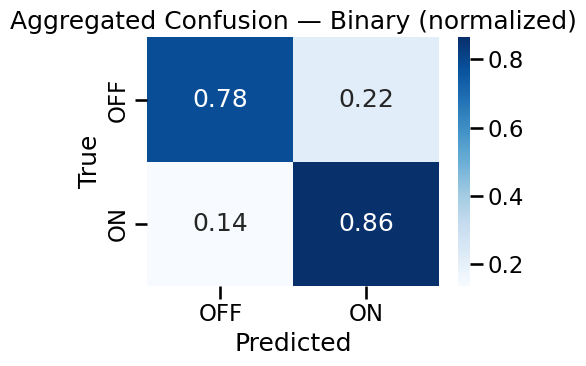


=== Aggregated Ternary (GT-anchored thresholds) ===
              precision    recall  f1-score   support

         OFF       0.82      0.96      0.89     11240
         LOW       0.41      0.24      0.31      2527
        HIGH       0.58      0.14      0.23      1125

    accuracy                           0.78     14892
   macro avg       0.61      0.45      0.47     14892
weighted avg       0.73      0.78      0.74     14892



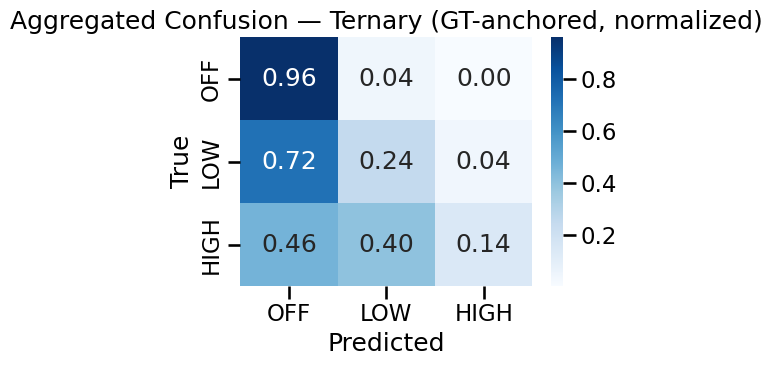


=== Aggregated Ternary (Matched-quantiles on predictions) ===
              precision    recall  f1-score   support

         OFF       0.99      0.49      0.66     11240
         LOW       0.21      0.53      0.30      2527
        HIGH       0.30      0.77      0.43      1125

    accuracy                           0.52     14892
   macro avg       0.50      0.60      0.46     14892
weighted avg       0.81      0.52      0.58     14892



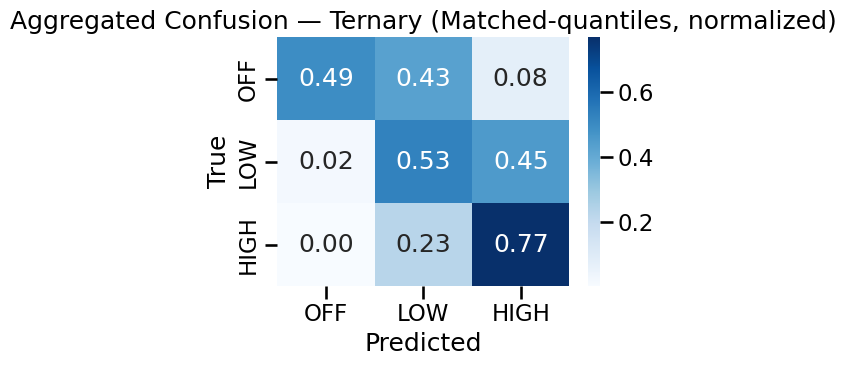

In [12]:
cms = confusion_eval_seq2point(cfg, houses, labeled_ids, scalers, model,
                               plot_per_house=False, save_dir="results_eval")